# Model fitting 1: Only SSC and extended radio jet

In [1]:
#import warnings
#warnings.filterwarnings('ignore')

import matplotlib.pylab as plt
import jetset
from jetset.test_data_helper import  test_SEDs
from jetset.data_loader import ObsData,Data
from jetset.plot_sedfit import PlotSED
from jetset.test_data_helper import  test_SEDs

In [2]:
print(jetset.__version__)

1.4.0rc1


In [3]:
test_SEDs

['/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_3C345.ecsv',
 '/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk421_EBL_DEABS.ecsv',
 '/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk501_EBL_ABS.ecsv',
 '/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk501_EBL_DEABS.ecsv']

## Loading data



In [4]:
print(test_SEDs[1])
data=Data.from_file(test_SEDs[1])


/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk421_EBL_DEABS.ecsv



***  binning data  ***
---> N bins= 88
---> bin_width= 0.2



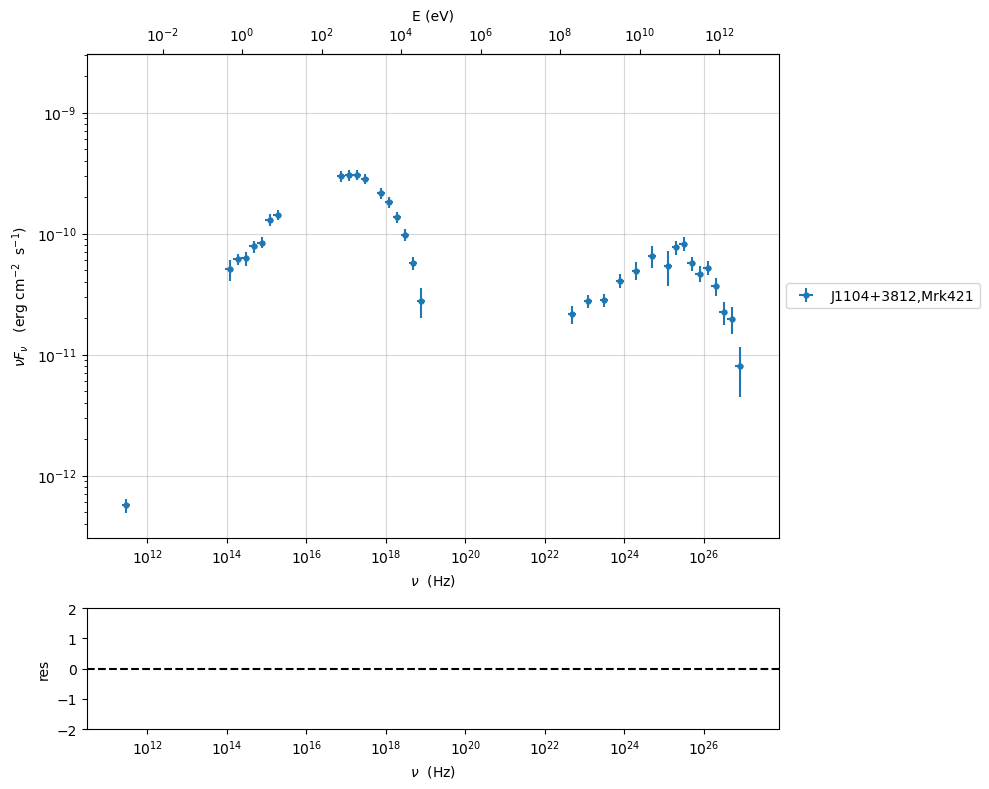

In [5]:
%matplotlib inline
sed_data=ObsData(data_table=data)
sed_data.group_data(bin_width=0.2)

sed_data.add_systematics(0.1,[10.**6,10.**29])
p=sed_data.plot_sed()
#p.setlim(y_min=1E-15,x_min=1E7,x_max=1E29)

In [6]:
sed_data.save('Mrk_401.pkl')

## phenomenological model constraining

### spectral indices


*** evaluating spectral indices for data ***



/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/scipy/optimize/_lsq/common.py:115: RuntimeWarning: overflow encountered in power
  phi_prime = -np.sum(suf ** 2 / denom**3) / p_norm
/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/scipy/optimize/_lsq/common.py:154: RuntimeWarning: invalid value encountered in scalar divide
  ratio = phi / phi_prime
/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/scipy/optimize/_lsq/common.py:398: RuntimeWarning: invalid value encountered in cast
  return min_step, np.equal(steps, min_step) * np.sign(s).astype(int)


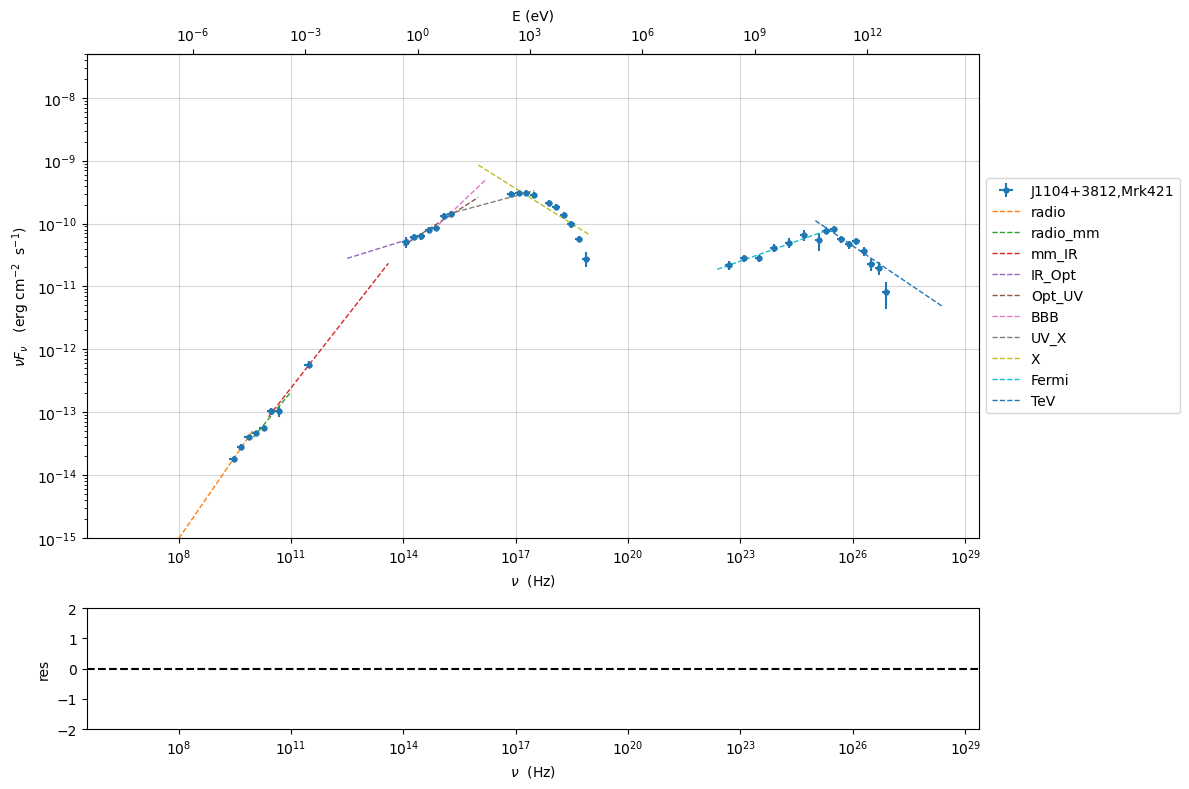

In [7]:
from jetset.sed_shaper import  SEDShape
my_shape=SEDShape(sed_data)
my_shape.eval_indices(minimizer='lsb',silent=True)
p=my_shape.plot_indices()
p.setlim(y_min=1E-15,y_max=5E-8)

### sed shaper

In [8]:
mm,best_fit=my_shape.sync_fit(check_host_gal_template=False,
                  Ep_start=None,
                  minimizer='lsb',
                  silent=True,
                  fit_range=[10.,21.])


*** Log-Polynomial fitting of the synchrotron component ***
---> first blind fit run,  fit range: [10.0, 21.0]
---> class:  HSP





model name,name,val,bestfit val,err +,err -,start val,fit range min,fit range max,frozen
LogCubic,b,-1.563747e-01,-1.563747e-01,5.975434e-03,--,-1.000000e+00,-1.000000e+01,0.000000e+00,False
LogCubic,c,-1.052802e-02,-1.052802e-02,8.781942e-04,--,-1.000000e+00,-1.000000e+01,1.000000e+01,False
LogCubic,Ep,1.675324e+01,1.675324e+01,2.396636e-02,--,1.670206e+01,0.000000e+00,3.000000e+01,False
LogCubic,Sp,-9.494365e+00,-9.494365e+00,1.704982e-02,--,-1.000000e+01,-3.000000e+01,0.000000e+00,False


---> sync       nu_p=+1.675324e+01 (err=+2.396636e-02)  nuFnu_p=-9.494365e+00 (err=+1.704982e-02) curv.=-1.563747e-01 (err=+5.975434e-03)




*** Log-Polynomial fitting of the IC component ***
---> fit range: [23.0, 29.0]
---> LogCubic fit




model name,name,val,bestfit val,err +,err -,start val,fit range min,fit range max,frozen
LogCubic,b,-2.274590e-01,-2.274590e-01,3.262165e-02,--,-1.000000e+00,-1.000000e+01,0.000000e+00,False
LogCubic,c,-6.259967e-02,-6.259967e-02,1.629407e-02,--,-1.000000e+00,-1.000000e+01,1.000000e+01,False
LogCubic,Ep,2.527207e+01,2.527207e+01,8.149544e-02,--,2.528644e+01,0.000000e+00,3.000000e+01,False
LogCubic,Sp,-1.014119e+01,-1.014119e+01,2.734754e-02,--,-1.000000e+01,-3.000000e+01,0.000000e+00,False


---> IC         nu_p=+2.527207e+01 (err=+8.149544e-02)  nuFnu_p=-1.014119e+01 (err=+2.734754e-02) curv.=-2.274590e-01 (err=+3.262165e-02)



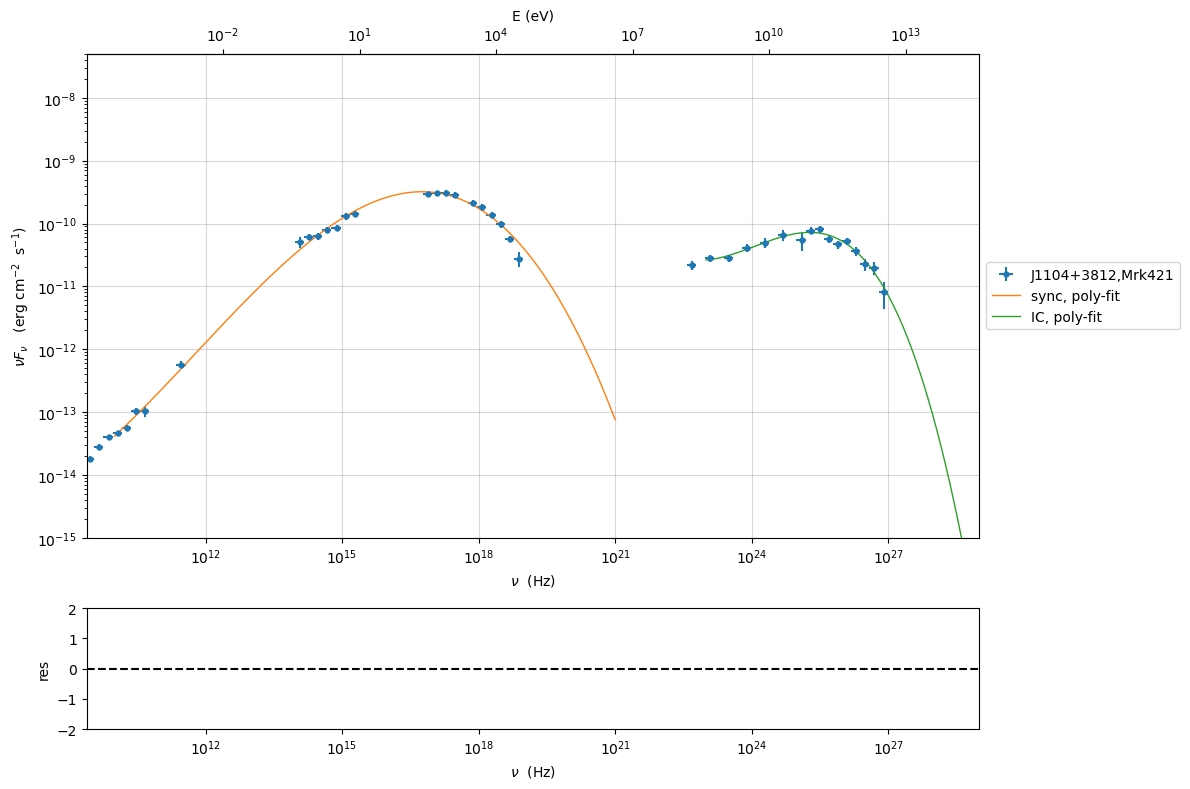

In [9]:
my_shape.IC_fit(fit_range=[23.,29.],minimizer='minuit',silent=True)
p=my_shape.plot_shape_fit()
p.setlim(y_min=1E-15,y_max=5E-8)

### Model constraining

In this step we are not fitting the model, we are just obtaining the phenomenological `pre_fit` model, that will be fitted in using minuit ore least-square bound, as shown below

In [10]:
from jetset.obs_constrain import ObsConstrain
from jetset.model_manager import  FitModel
sed_obspar=ObsConstrain(beaming=25,
                        B_range=[0.001,0.1],
                        distr_e='lppl',
                        t_var_sec=3*86400,
                        nu_cut_IR=1E12,
                        SEDShape=my_shape)


prefit_jet=sed_obspar.constrain_SSC_model(electron_distribution_log_values=False,silent=True)
prefit_jet.save_model('prefit_jet.pkl')


***  constrains parameters from observable ***



/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/obs_constrain.py:1514: RankWarning: Polyfit may be poorly conditioned
  p=polyfit(nu_p_IC_model_log,B_grid_log,2)


model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_leptonic,R,region_size,cm,3.452668e+16,1.000000e+03,1.000000e+30,False,False
jet_leptonic,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_leptonic,B,magnetic_field,gauss,5.050000e-02,0.000000e+00,--,False,False
jet_leptonic,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
jet_leptonic,beam_obj,beaming,,2.500000e+01,1.000000e-04,--,False,False
jet_leptonic,z_cosm,redshift,,3.080000e-02,0.000000e+00,--,False,False
jet_leptonic,gmin,low-energy-cut-off,lorentz-factor*,4.697542e+02,1.000000e+00,1.000000e+09,False,False
jet_leptonic,gmax,high-energy-cut-off,lorentz-factor*,1.300733e+06,1.000000e+00,1.000000e+15,False,False
jet_leptonic,N,emitters_density,1 / cm3,6.119093e-01,0.000000e+00,--,False,False
jet_leptonic,gamma0_log_parab,turn-over-energy,lorentz-factor*,3.290961e+04,1.000000e+00,1.000000e+09,False,False


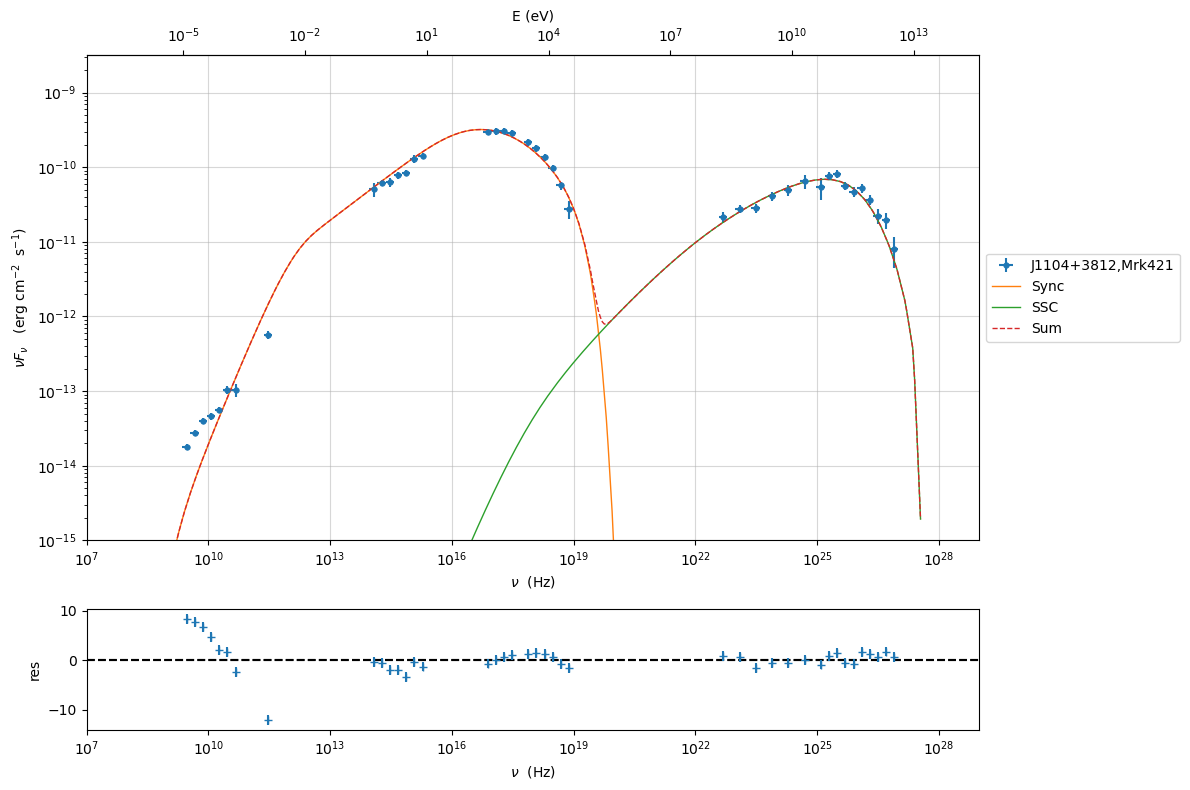

In [11]:
prefit_jet.eval()
pl=prefit_jet.plot_model(sed_data=sed_data)
pl.add_residual_plot(prefit_jet,sed_data)
pl.setlim(y_min=1E-15,x_min=1E7,x_max=1E29)

## Model fitting procedure

### Model fitting with Minuit

In [12]:
from jetset.minimizer import fit_SED,ModelMinimizer

from jetset.model_manager import  FitModel
from jetset.jet_model import Jet


In [13]:
from jetset.jet_radio_component import RadioSpectrum
radio_spectrum=RadioSpectrum()

if you want to fit the `prefit_model` you can load the saved one (this allows you to save time) ad pass it to the `FitModel` class

In [14]:
prefit_jet=Jet.load_model('prefit_jet.pkl')
fit_model=FitModel( jet=prefit_jet, name='SSC-best-fit-lsb',template=None) 


/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/model_manager.py:259: UserWarning: no cosmology defined, using the one from jet FlatLambdaCDM(name="Planck13", H0=67.77 km / (Mpc s), Om0=0.30712, Tcmb0=2.7255 K, Neff=3.046, m_nu=[0.   0.   0.06] eV, Ob0=0.048252)
  warnings.warn(m)


In [15]:
fit_model.add_component(radio_spectrum)

OR use the one generated above

In [16]:
fit_model.show_model_components()


--------------------------------------------------------------------------------
Composite model description
--------------------------------------------------------------------------------
name: SSC-best-fit-lsb  
type: composite_model  
components models:
 -model name: jet_leptonic model type: jet
 -model name: radio_spectrum model type: radio_spectrum

--------------------------------------------------------------------------------


There are now two components:  `jet_leptonic` and  `radio_spectrum`

We now set the gamma grid size to 200, ad we set `composite_expr`, anyhow, since we have only one component this step could be skipped

In [17]:
fit_model.jet_leptonic.set_gamma_grid_size(200)
fit_model.composite_expr='(jet_leptonic+radio_spectrum)'

In [18]:
fit_model.parameters

model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_leptonic,gmin,low-energy-cut-off,lorentz-factor*,4.697542e+02,1.000000e+00,1.000000e+09,False,False
jet_leptonic,gmax,high-energy-cut-off,lorentz-factor*,1.300733e+06,1.000000e+00,1.000000e+15,False,False
jet_leptonic,N,emitters_density,1 / cm3,6.119093e-01,0.000000e+00,--,False,False
jet_leptonic,gamma0_log_parab,turn-over-energy,lorentz-factor*,3.290961e+04,1.000000e+00,1.000000e+09,False,False
jet_leptonic,s,LE_spectral_slope,,2.169388e+00,-1.000000e+01,1.000000e+01,False,False
jet_leptonic,r,spectral_curvature,,7.818737e-01,-1.500000e+01,1.500000e+01,False,False
jet_leptonic,R,region_size,cm,3.452668e+16,1.000000e+03,1.000000e+30,False,False
jet_leptonic,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_leptonic,B,magnetic_field,gauss,5.050000e-02,0.000000e+00,--,False,False
jet_leptonic,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True


None

#### Freezeing parameters and setting fit_range intervals

These methods are alternative and equivalent ways to access a model component for setting parameters state and values or freezing 


a) passing as first argument, of the method, the model component `name` and as second the `parameter name`


b) accessing the model component member of the composite model class, and accessing the `parameter` object member  

In [19]:
#a
fit_model.freeze('jet_leptonic','z_cosm')


#b
fit_model.jet_leptonic.parameters.R_H.frozen=True

fit_model.jet_leptonic.parameters.R.fit_range=[10**15.5,10**17.5]
fit_model.jet_leptonic.parameters.beam_obj.fit_range=[5., 50.]
fit_model.jet_leptonic.parameters.B.fit_range=[1E-3, 1]
fit_model.jet_leptonic.parameters.s.fit_range=[1, 3]
fit_model.jet_leptonic.parameters.r.fit_range=[.1, 2]
fit_model.jet_leptonic.parameters.gamma0_log_parab.fit_range=[1000, 1E6]
fit_model.jet_leptonic.parameters.gmin.fit_range=[2, 5E3]
fit_model.jet_leptonic.parameters.gmax.fit_range=[1E4, 1E7]


fit_model.radio_spectrum.parameters.nu_ssa.fit_range=[1E7, 5E10]
fit_model.radio_spectrum.parameters.nuFnu_p.fit_range=[1E-14, 1E-12]



#### Building the ModelMinimizer object

In [20]:
model_minimizer=ModelMinimizer('minuit')


**Since the pre-fit model was very close to the data, we degrade the model in order to provide a more robust benchmark to the fitter, but this is not required!!!**

In [21]:
fit_model.jet_leptonic.parameters.N.val=1
fit_model.jet_leptonic.parameters.r.val=1.0
fit_model.jet_leptonic.parameters.beam_obj.val=20
fit_model.eval()

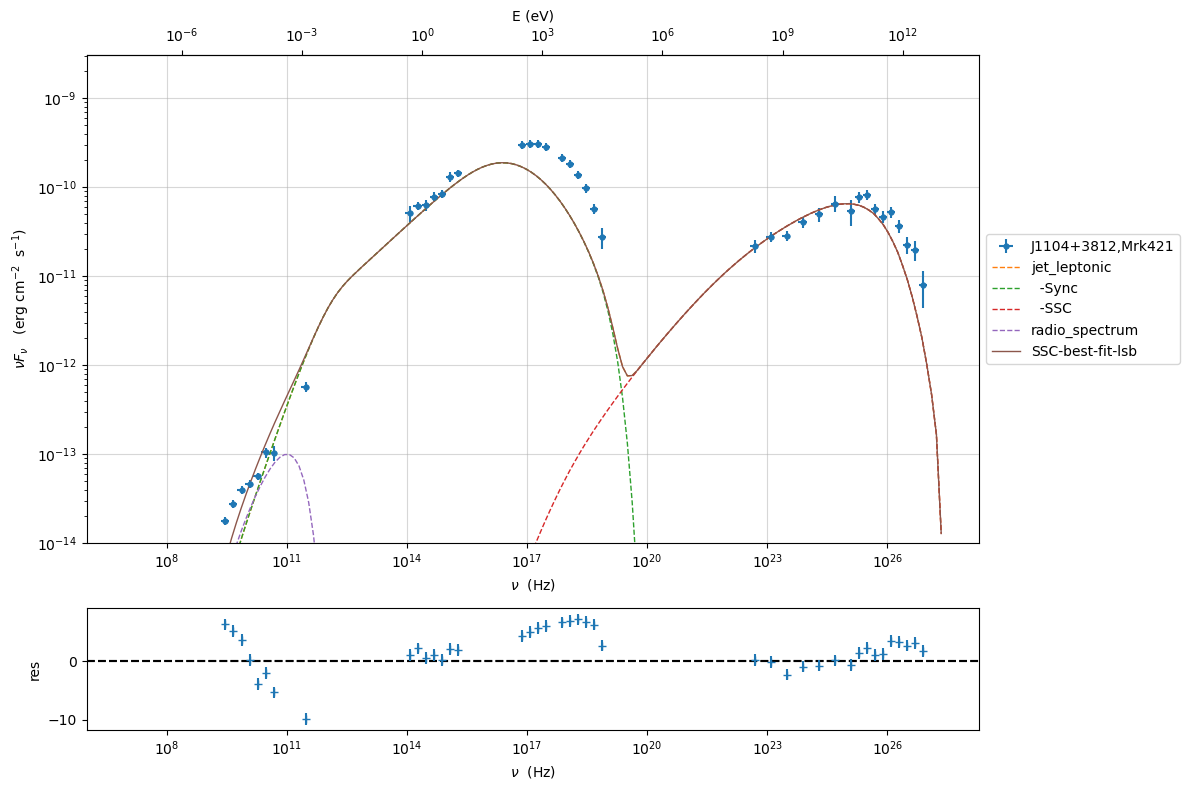

In [22]:
%matplotlib inline
fit_model.set_nu_grid(1E6,1E30,200)
fit_model.eval()
p2=fit_model.plot_model(sed_data=sed_data)
p2.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

In [23]:
best_fit_res=model_minimizer.fit(fit_model,
                                     sed_data,
                                     1E7,
                                     1E29,
                                     fitname='SSC-best-fit-minuit',
                                     repeat=1)

filtering data in fit range = [1.000000e+07,1.000000e+29]
data length 41

*** start fit process ***
----- 


0it [00:00, ?it/s]

- best chisq=2.31038e+01

-------------------------------------------------------------------------
Fit report

Model: SSC-best-fit-minuit


model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_leptonic,gmin,low-energy-cut-off,lorentz-factor*,6.763682e+02,1.000000e+00,1.000000e+09,False,False
jet_leptonic,gmax,high-energy-cut-off,lorentz-factor*,7.324947e+05,1.000000e+00,1.000000e+15,False,False
jet_leptonic,N,emitters_density,1 / cm3,8.769818e-01,0.000000e+00,--,False,False
jet_leptonic,gamma0_log_parab,turn-over-energy,lorentz-factor*,3.459271e+04,1.000000e+00,1.000000e+09,False,False
jet_leptonic,s,LE_spectral_slope,,2.218899e+00,-1.000000e+01,1.000000e+01,False,False
jet_leptonic,r,spectral_curvature,,6.831036e-01,-1.500000e+01,1.500000e+01,False,False
jet_leptonic,R,region_size,cm,1.961992e+16,1.000000e+03,1.000000e+30,False,False
jet_leptonic,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_leptonic,B,magnetic_field,gauss,5.720871e-02,0.000000e+00,--,False,False
jet_leptonic,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True



converged=True
calls=4864
mesg=


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 23.1                       │             Nfcn = 4864              │
│ EDM = 9e+03 (Goal: 0.0002)       │            time = 5.0 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   ABOVE EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │     Covariance FORCED pos. def.      │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name   │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ par_0  │    676    │     6     │            │            │    2    │  5000   │       │
│ 1 │ par_1  │  0.73e6   │  0.10e6   │            │            │  10000  │  1e+07  │       │
│ 2 │ par_2  │   0.877   │   0.030   │            │            │    0    │         │       │
│ 3 │ par_3  │  34.59e3  │  0.05e3   │            │            │  1000   │  1e+06  │       │
│ 4 │ par_4  │ 2.218899  │ 0.000023  │            │            │    1    │    3    │       │
│ 5 │ par_5  │683.104e-3 │ 0.030e-3  │            │            │   0.1   │    2    │       │
│ 6 │ par_6  │  19.6e15  │  0.6e15   │            │            │3.16228e+15│3.16228e+17│       │
│ 7 │ par_7  │ 57.209e-3 │ 0.011e-3  │            │            │  0.001  │    1    │       │
│ 8 │ par_8  │   29.9    │    0.4    │            │            │    5    │   50    │       │
│ 9 │ par_9  │   0.790   │   0.015   │            │            │   -10   │   10    │       │
│ 10│ par_10 │  0.86e9   │  0.08e9   │            │            │  1e+07  │  5e+10  │       │
│ 11│ par_11 │  0.15e12  │  0.04e12  │            │            │  1e+06  │  1e+13  │       │
│ 12│ par_12 │ 33.1e-15  │  1.4e-15  │            │            │  1e-14  │  1e-12  │       │
└───┴────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘

dof=28
chisq=23.103806, chisq/red=0.825136 null hypothesis sig=0.727828

best fit pars


model name,name,val,bestfit val,err +,err -,start val,fit range min,fit range max,frozen
jet_leptonic,gmin,6.763682e+02,6.763682e+02,6.317549e+00,--,4.697542e+02,2.000000e+00,5.000000e+03,False
jet_leptonic,gmax,7.324947e+05,7.324947e+05,1.042334e+05,--,1.300733e+06,1.000000e+04,1.000000e+07,False
jet_leptonic,N,8.769818e-01,8.769818e-01,3.049989e-02,--,1.000000e+00,0.000000e+00,--,False
jet_leptonic,gamma0_log_parab,3.459271e+04,3.459271e+04,4.588952e+01,--,3.290961e+04,1.000000e+03,1.000000e+06,False
jet_leptonic,s,2.218899e+00,2.218899e+00,2.322968e-05,--,2.169388e+00,1.000000e+00,3.000000e+00,False
jet_leptonic,r,6.831036e-01,6.831036e-01,3.024734e-05,--,1.000000e+00,1.000000e-01,2.000000e+00,False
jet_leptonic,R,1.961992e+16,1.961992e+16,5.747664e+14,--,3.452668e+16,3.162278e+15,3.162278e+17,False
jet_leptonic,R_H,1.000000e+17,--,--,--,1.000000e+17,0.000000e+00,--,True
jet_leptonic,B,5.720871e-02,5.720871e-02,1.089890e-05,--,5.050000e-02,1.000000e-03,1.000000e+00,False
jet_leptonic,NH_cold_to_rel_e,1.000000e+00,--,--,--,1.000000e+00,0.000000e+00,--,True


-------------------------------------------------------------------------




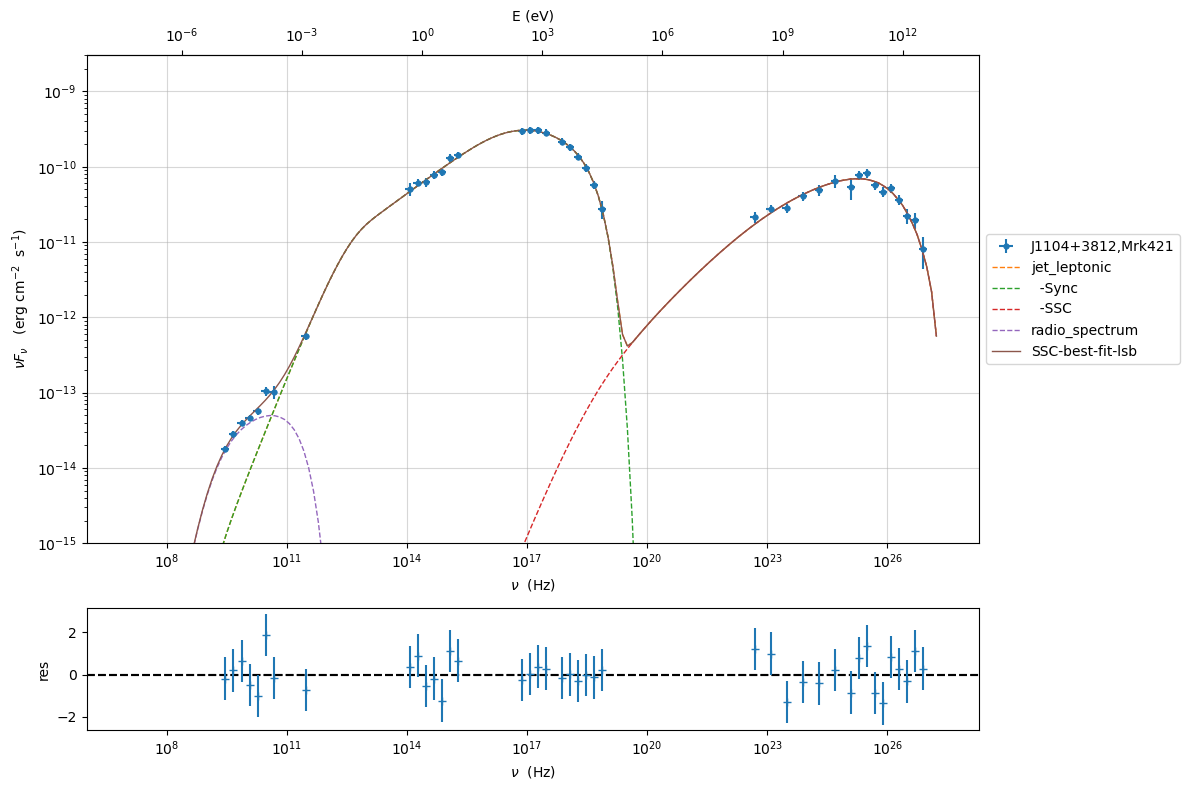

In [24]:
%matplotlib inline
fit_model.set_nu_grid(1E6,1E30,200)
fit_model.eval()
p2=fit_model.plot_model(sed_data=sed_data)
p2.setlim(y_min=1E-15,x_min=1E6,x_max=2E28)

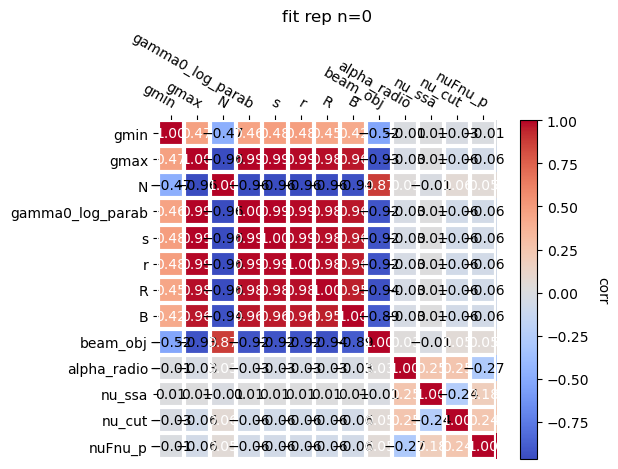

In [25]:
p=model_minimizer.plot_corr_matrix()

#### saving fit model, model minimizer

We can save all the fit products to be used later.

In [26]:

best_fit_res.save_report('SSC-best-fit.pkl')
model_minimizer.save_model('model_minimizer.pkl')
fit_model.save_model('fit_model.pkl')

#### saving fit model, model minimizer

In [27]:
best_fit.save_report('SSC-best-fit.pkl')
model_minimizer.save_model('model_minimizer.pkl')
fit_model.save_model('fit_model.pkl')

You can obtain profile and contours, but this is typically time consuming. In any case, better results can be achieved using the MCMC approach (discussed in next section).
For further information regarding minuit please refer to https://iminuit.readthedocs.io

you can use also minos contour and profile, in this case the computational time is even longer:

## MCMC sampling

### creating and setting the sampler

In [28]:
from jetset.data_loader import ObsData

sed_data=ObsData.load('Mrk_401.pkl')

In [29]:
from jetset.mcmc import McmcSampler
from jetset.minimizer import ModelMinimizer


In [30]:
model_minimizer = ModelMinimizer.load_model('model_minimizer.pkl')

mcmc=McmcSampler(model_minimizer)


You can inspect the mcmc parameters using:

In [31]:
mcmc.sampler_parameters

model name,name,val,bestfit mcmc,q16,q50,q84,mcmc bound min,mcmc bound max,frozen
str14,str16,float64,float64,float64,float64,float64,float64,float64,bool
jet_leptonic,gmin,6.763682e+02,6.763682e+02,--,--,--,2.000000e+00,5.000000e+03,False
jet_leptonic,gmax,7.324947e+05,7.324947e+05,--,--,--,1.000000e+04,1.000000e+07,False
jet_leptonic,N,8.769818e-01,8.769818e-01,--,--,--,0.000000e+00,--,False
jet_leptonic,gamma0_log_parab,3.459271e+04,3.459271e+04,--,--,--,1.000000e+03,1.000000e+06,False
jet_leptonic,s,2.218899e+00,2.218899e+00,--,--,--,1.000000e+00,3.000000e+00,False
jet_leptonic,r,6.831036e-01,6.831036e-01,--,--,--,1.000000e-01,2.000000e+00,False
jet_leptonic,R,1.961992e+16,1.961992e+16,--,--,--,3.162278e+15,3.162278e+17,False
jet_leptonic,R_H,1.000000e+17,--,--,--,--,0.000000e+00,--,True
jet_leptonic,B,5.720871e-02,5.720871e-02,--,--,--,1.000000e-03,1.000000e+00,False


If you want to exclude or include parameters from the samplers just freeze/free them 

In [32]:
mcmc.model.radio_spectrum.parameters.nu_ssa.frozen=True


You can set different bounds for all the free parameters with the instruction below. In case you want to preserve the `fit_range` defined in the frequentist minimizer you can pass `preserve_fit_range=True`

In [33]:
mcmc.set_bounds(bound=5.0,bound_rel=True)

par: gmin  ref value:  676.3681759111445  mcmc bounds: [2, np.float64(4058.209055466867)]
par: gmax  ref value:  732494.6685527716  mcmc bounds: [10000.0, np.float64(4394968.011316629)]
par: N  ref value:  0.8769817811911864  mcmc bounds: [0, np.float64(5.261890687147118)]
par: gamma0_log_parab  ref value:  34592.70847910582  mcmc bounds: [1000, np.float64(207556.25087463492)]
par: s  ref value:  2.218898983458562  mcmc bounds: [1, 3]
par: r  ref value:  0.6831035549353696  mcmc bounds: [0.1, 2]
par: R  ref value:  1.961992149348541e+16  mcmc bounds: [3162277660168379.5, np.float64(1.1771952896091245e+17)]
par: B  ref value:  0.05720870936568684  mcmc bounds: [0.001, np.float64(0.34325225619412103)]
par: beam_obj  ref value:  29.862032853034325  mcmc bounds: [5.0, 50.0]
par: alpha_radio  ref value:  0.7904382016657108  mcmc bounds: [np.float64(-3.161752806662843), np.float64(4.742629209994265)]
par: nu_cut  ref value:  147407027504.47702  mcmc bounds: [1000000.0, np.float64(88444216502

Or, you can set per-parameter bounds as follows, passing the actual bound for each parameter.

In [34]:
mcmc.set_bounds(comp_name='jet_leptonic',par_name='N',par_bounds=[1E-5,10])
mcmc.set_bounds(comp_name='radio_spectrum',par_name='alpha_radio',par_bounds=[0,1])

par: N  ref value:  0.8769817811911864  mcmc bounds: [1e-05, 10]
par: alpha_radio  ref value:  0.7904382016657108  mcmc bounds: [0, 1]


In [35]:
mcmc.sampler_parameters

model name,name,val,bestfit mcmc,q16,q50,q84,mcmc bound min,mcmc bound max,frozen
str14,str16,float64,float64,float64,float64,float64,float64,float64,bool
jet_leptonic,gmin,6.763682e+02,6.763682e+02,--,--,--,2.000000e+00,4.058209e+03,False
jet_leptonic,gmax,7.324947e+05,7.324947e+05,--,--,--,1.000000e+04,4.394968e+06,False
jet_leptonic,N,8.769818e-01,8.769818e-01,--,--,--,1.000000e-05,1.000000e+01,False
jet_leptonic,gamma0_log_parab,3.459271e+04,3.459271e+04,--,--,--,1.000000e+03,2.075563e+05,False
jet_leptonic,s,2.218899e+00,2.218899e+00,--,--,--,1.000000e+00,3.000000e+00,False
jet_leptonic,r,6.831036e-01,6.831036e-01,--,--,--,1.000000e-01,2.000000e+00,False
jet_leptonic,R,1.961992e+16,1.961992e+16,--,--,--,3.162278e+15,1.177195e+17,False
jet_leptonic,R_H,1.000000e+17,--,--,--,--,0.000000e+00,--,True
jet_leptonic,B,5.720871e-02,5.720871e-02,--,--,--,1.000000e-03,3.432523e-01,False


In [36]:
mcmc.run_sampler(nwalkers=30, burnin=50,steps=500,progress='notebook')


mcmc run starting



  0%|          | 0/500 [00:00<?, ?it/s]

mcmc run done, with 1 threads took 23.57 seconds
----------------------------
MCMC best fit solution
comp: jet_leptonic par: gmin  mcmc best fit val: 722.2353554059794 quantiles(0.16,0.5,0.84): [637.82918589 708.11963345 810.69611517] 
comp: jet_leptonic par: gmax  mcmc best fit val: 754171.4383976357 quantiles(0.16,0.5,0.84): [690735.79278987 766178.59069951 876777.30624545] 
comp: jet_leptonic par: N  mcmc best fit val: 0.8829585129281385 quantiles(0.16,0.5,0.84): [0.74514336 0.84956905 0.99766061] 
comp: jet_leptonic par: gamma0_log_parab  mcmc best fit val: 41725.50267723936 quantiles(0.16,0.5,0.84): [30972.3072401  38440.31455087 51931.65450149] 
comp: jet_leptonic par: s  mcmc best fit val: 2.245824006294547 quantiles(0.16,0.5,0.84): [2.17512146 2.24241551 2.30383302] 
comp: jet_leptonic par: r  mcmc best fit val: 0.7513978702936552 quantiles(0.16,0.5,0.84): [0.63093259 0.77073464 0.92421537] 
comp: jet_leptonic par: R  mcmc best fit val: 1.8479032027199424e+16 quantiles(0.16,0.5

Showing the MCMC parameters. Now MCMC bestfit values are updated to the best-fit MCMC solution


In [37]:
mcmc.sampler_parameters

model name,name,val,bestfit mcmc,q16,q50,q84,mcmc bound min,mcmc bound max,frozen
str14,str16,float64,float64,float64,float64,float64,float64,float64,bool
jet_leptonic,gmin,7.222354e+02,7.222354e+02,6.378292e+02,7.081196e+02,8.106961e+02,2.000000e+00,4.058209e+03,False
jet_leptonic,gmax,7.541714e+05,7.541714e+05,6.907358e+05,7.661786e+05,8.767773e+05,1.000000e+04,4.394968e+06,False
jet_leptonic,N,8.829585e-01,8.829585e-01,7.451434e-01,8.495691e-01,9.976606e-01,1.000000e-05,1.000000e+01,False
jet_leptonic,gamma0_log_parab,4.172550e+04,4.172550e+04,3.097231e+04,3.844031e+04,5.193165e+04,1.000000e+03,2.075563e+05,False
jet_leptonic,s,2.245824e+00,2.245824e+00,2.175121e+00,2.242416e+00,2.303833e+00,1.000000e+00,3.000000e+00,False
jet_leptonic,r,7.513979e-01,7.513979e-01,6.309326e-01,7.707346e-01,9.242154e-01,1.000000e-01,2.000000e+00,False
jet_leptonic,R,1.847903e+16,1.847903e+16,1.718877e+16,1.884292e+16,2.118421e+16,3.162278e+15,1.177195e+17,False
jet_leptonic,R_H,1.000000e+17,--,--,--,--,0.000000e+00,--,True
jet_leptonic,B,5.233642e-02,5.233642e-02,4.970970e-02,5.769336e-02,6.429220e-02,1.000000e-03,3.432523e-01,False


### plotting the posterior corner plot

To have a better rendering on the scatter plot, we redefine the plot labels

In [38]:
mcmc.set_plot_label('N',r'$N$',comp_name='jet_leptonic')
mcmc.set_plot_label('B',r'$B$',comp_name='jet_leptonic')
mcmc.set_plot_label('gmin',r'$\gamma_{\rm min}$',comp_name='jet_leptonic')
mcmc.set_plot_label('gmax',r'$\gamma_{\rm max}$',comp_name='jet_leptonic')
mcmc.set_plot_label('beam_obj',r'$\delta$',comp_name='jet_leptonic')
mcmc.set_plot_label('s',r'$s$',comp_name='jet_leptonic')
mcmc.set_plot_label('r',r'$r$',comp_name='jet_leptonic')
mcmc.set_plot_label('gamma0_log_parab',r'$\gamma_0$',comp_name='jet_leptonic')
mcmc.set_plot_label('alpha_radio',r'$\alpha_{\rm Radio}$',comp_name='radio_spectrum')
mcmc.set_plot_label('nu_cut',r'$\nu_{\rm cut}$',comp_name='radio_spectrum')
mcmc.set_plot_label('nuFnu_p',r'$\nu F_{\nu}^{p}$',comp_name='radio_spectrum')

the code below lets you tuning the output

1) mpl.rcParams['figure.dpi'] if you increase it you get a better definition
2) title_fmt=".2E" this is the format for python, 2 significant digits, scientific notation
3) title_kwargs=dict(fontsize=12) you can change the fontsize

Per-component corner plot

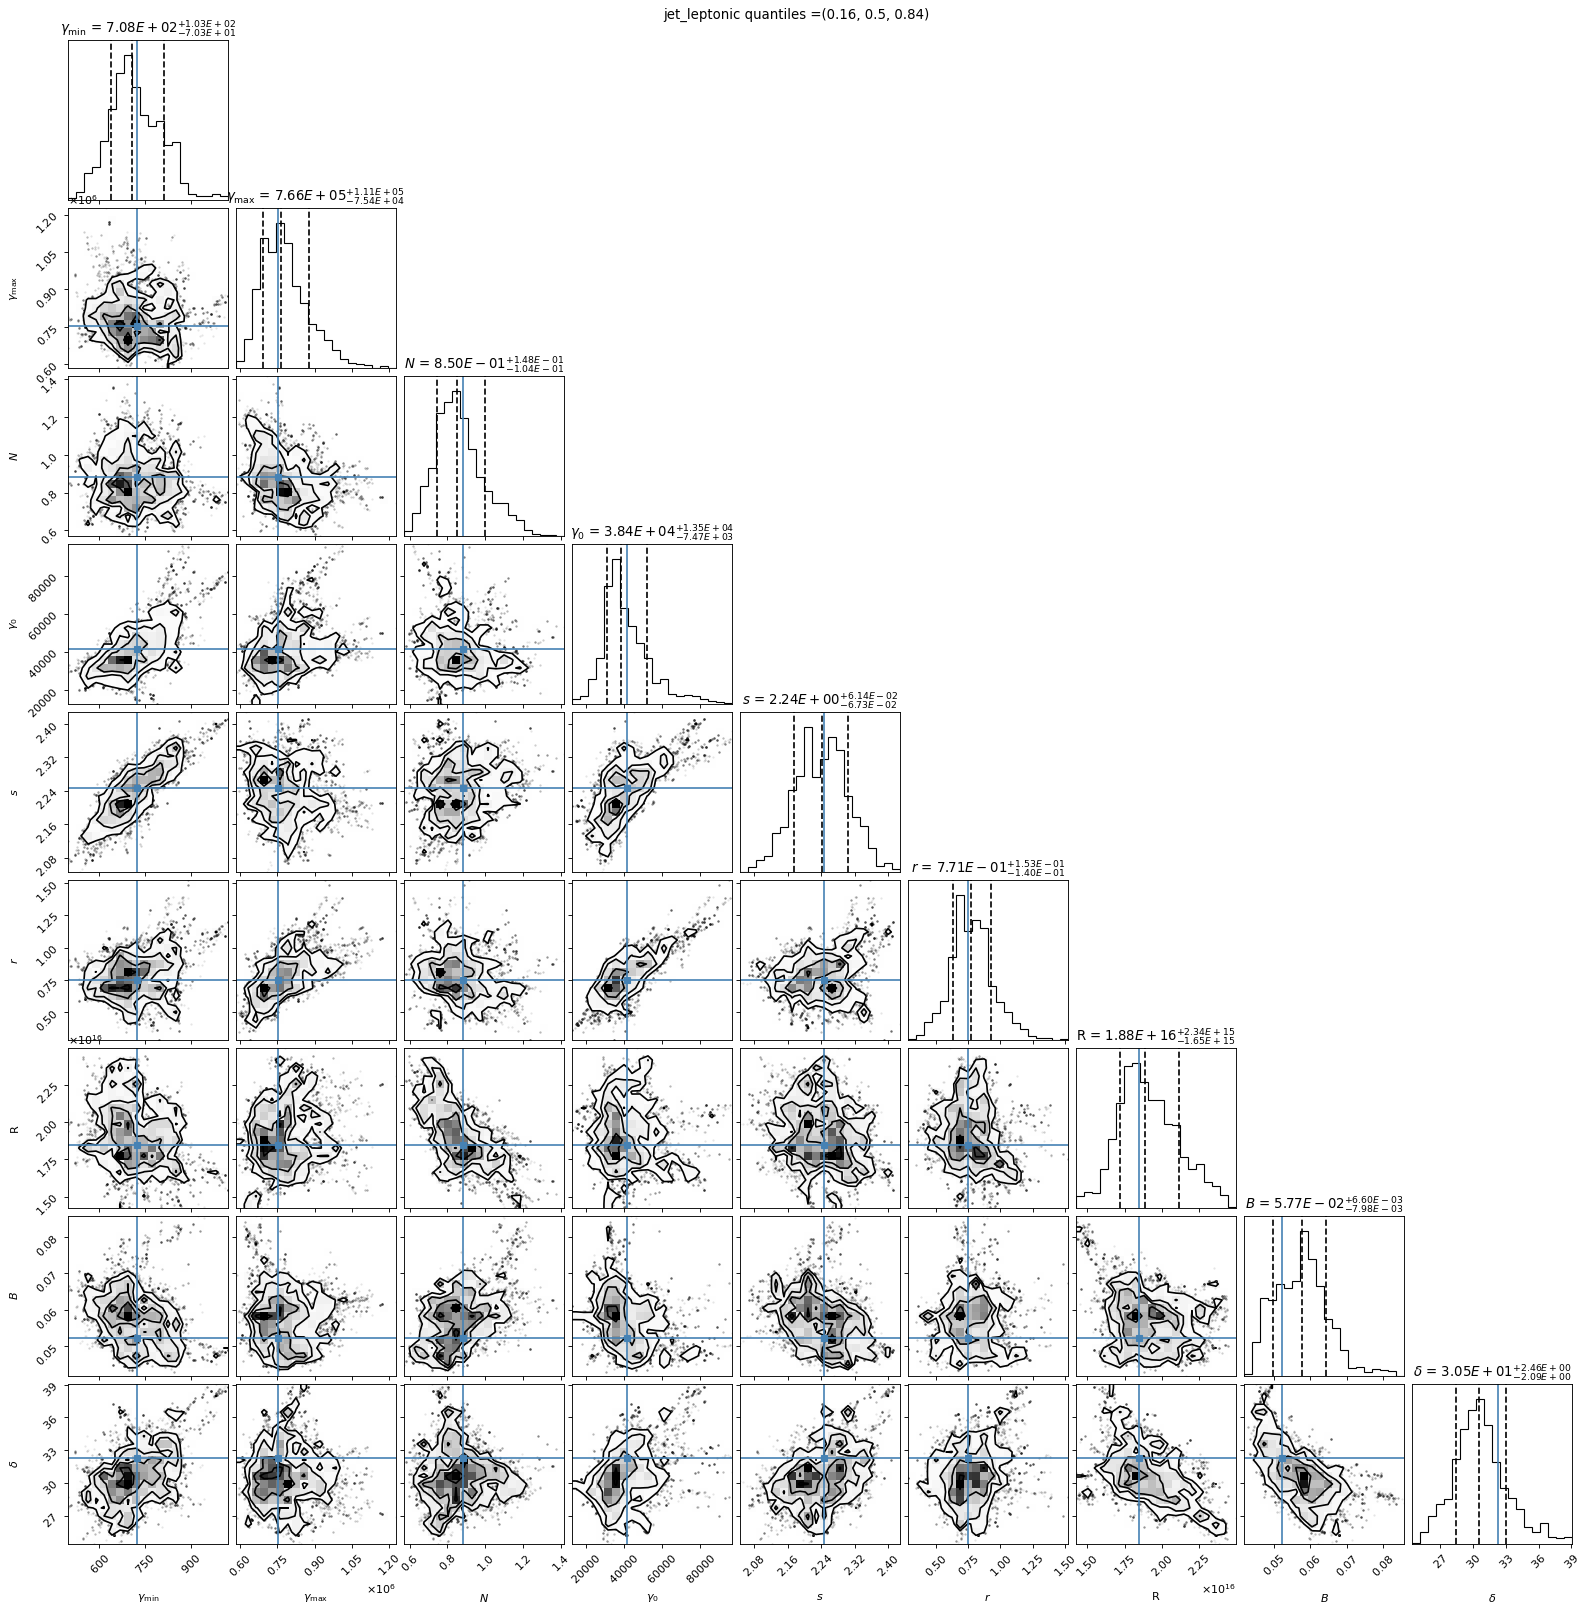

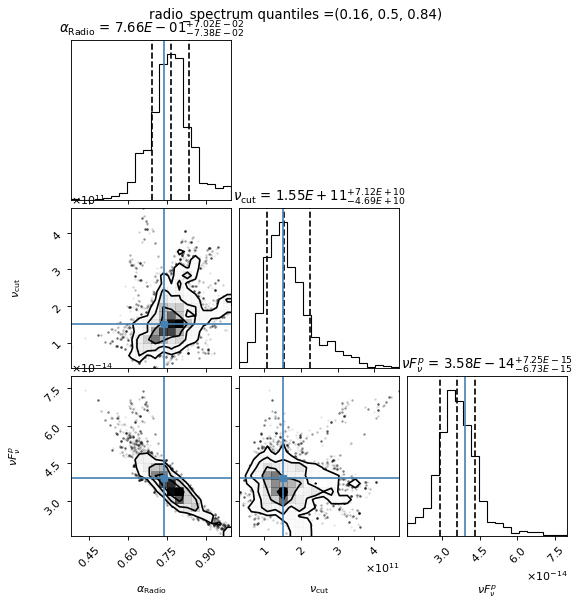

In [39]:
import matplotlib as mpl

mpl.rcParams['figure.dpi'] = 80
f=mcmc.corner_plot(quantiles=(0.16, 0.5, 0.84),title_kwargs=dict(fontsize=12),title_fmt=".2E",use_math_text=True)

Global corner plot, pass `per_component=False`


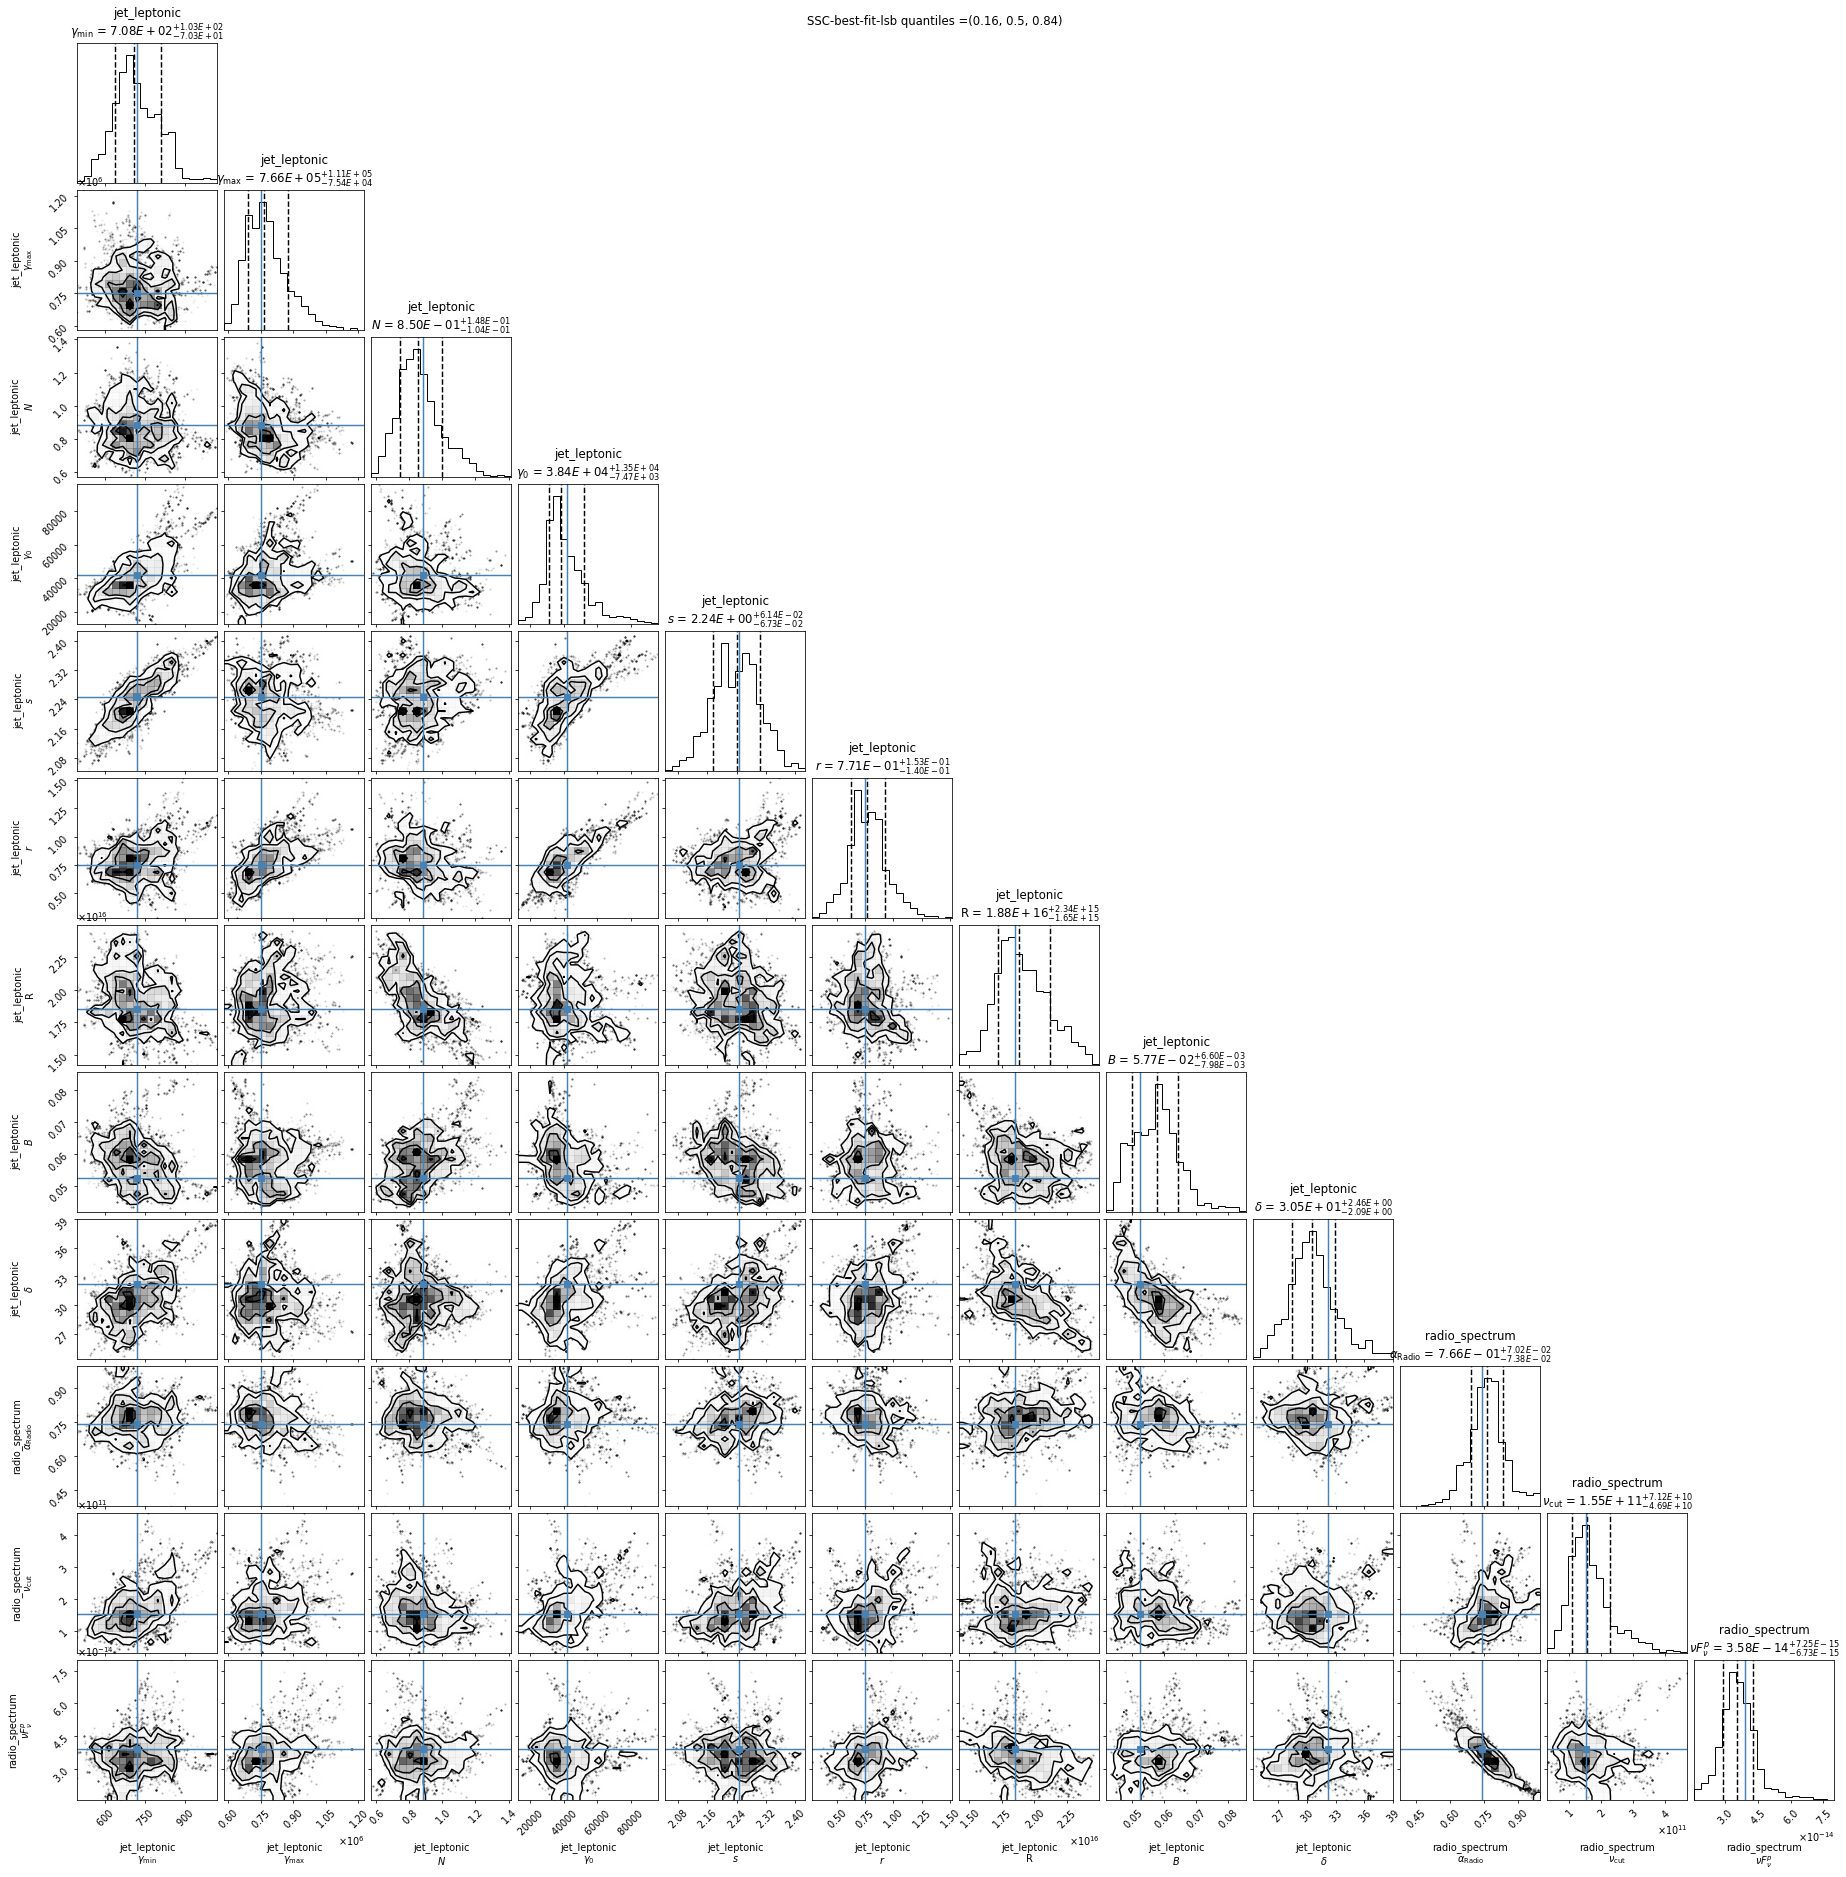

In [40]:
mpl.rcParams['figure.dpi'] = 70
f=mcmc.corner_plot(quantiles=(0.16, 0.5, 0.84),title_kwargs=dict(fontsize=12),title_fmt=".2E",use_math_text=True,per_component=False)

In [41]:
print(mcmc.acceptance_fraction)

0.27746666666666664


### plotting the model

To plot the sampled model range against the input mcmc best-fit model

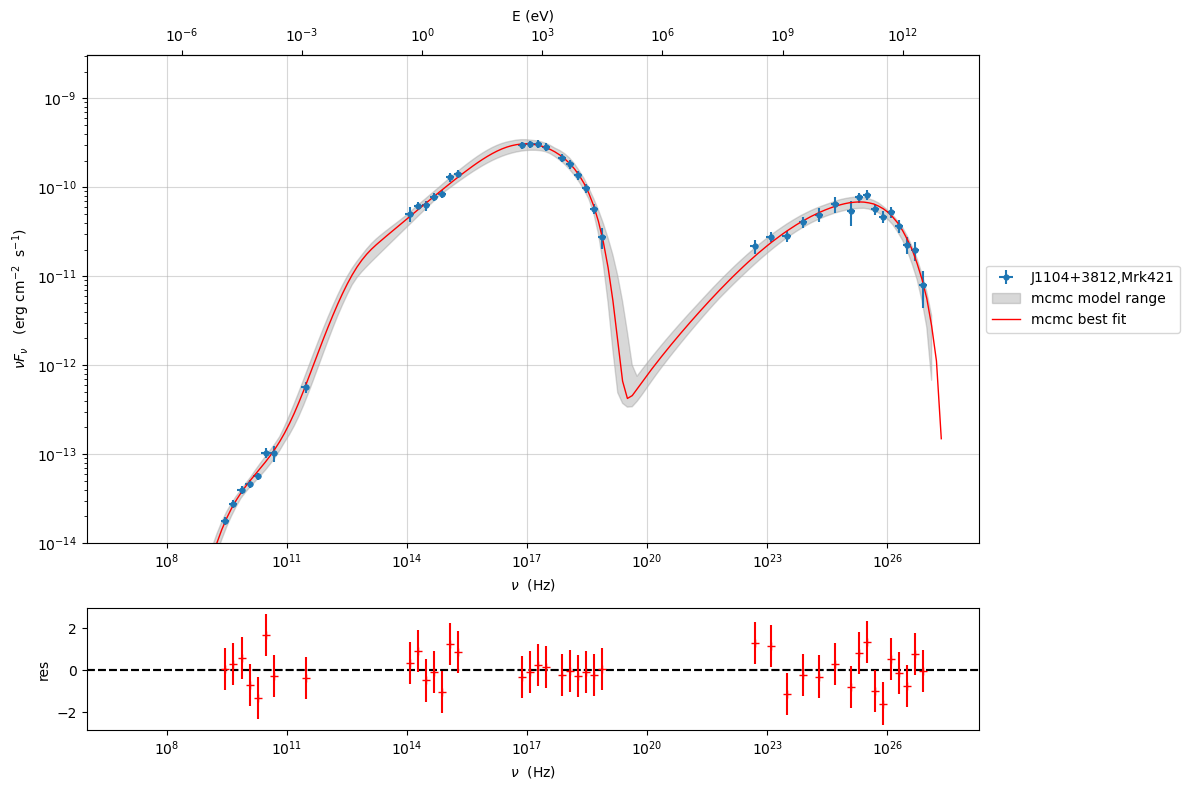

In [42]:

from jetset.data_loader import ObsData
sed_data=ObsData.load('Mrk_401.pkl')
mpl.rcParams['figure.dpi'] = 80
p=mcmc.plot_model(sed_data=sed_data,fit_range=[1E7,1E29],size=100)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

To plot the mcmc best-fit model providing quantiles. The size parameter defines the number of samples to use to extract the quantiles. I am using a size equal to the number of steps

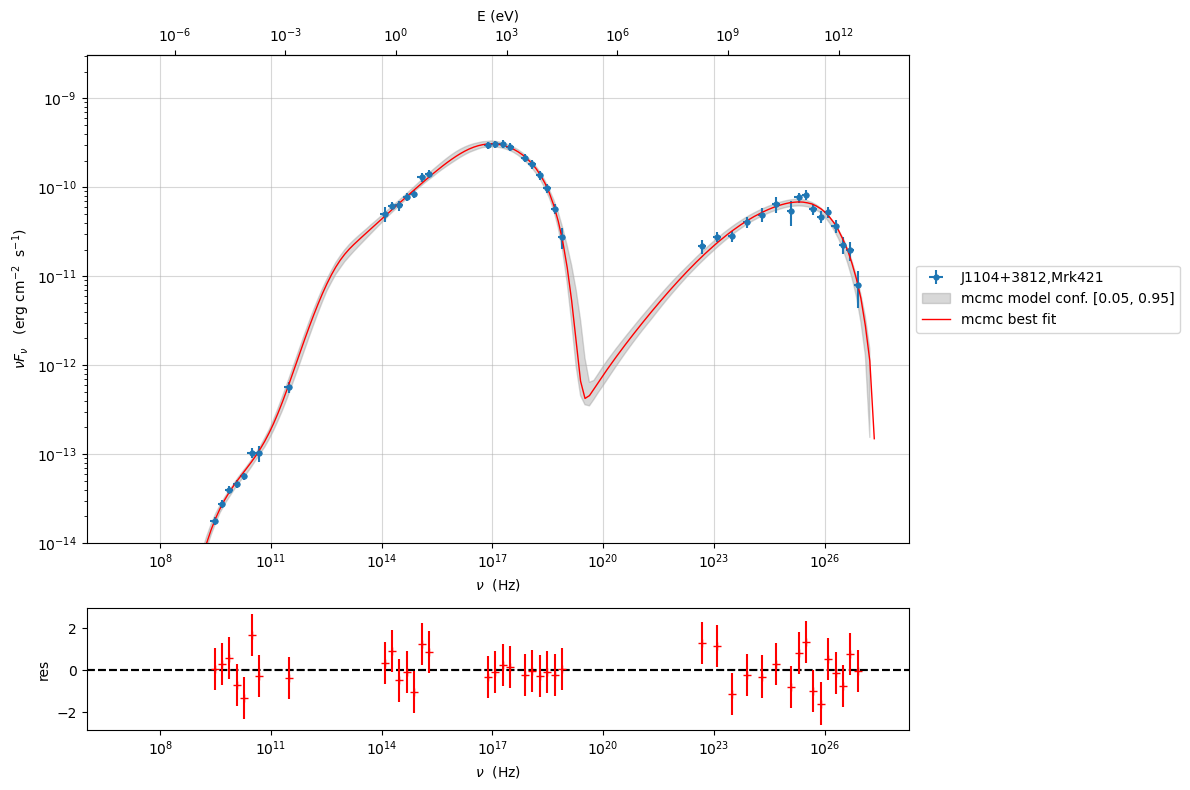

In [43]:
mpl.rcParams['figure.dpi'] = 80
p=mcmc.plot_model(sed_data=sed_data,fit_range=[1E7, 2E29],size=100,quantiles=[0.05,0.95])
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

If you want to plot also the model components, pass the argument `plot_components=True`

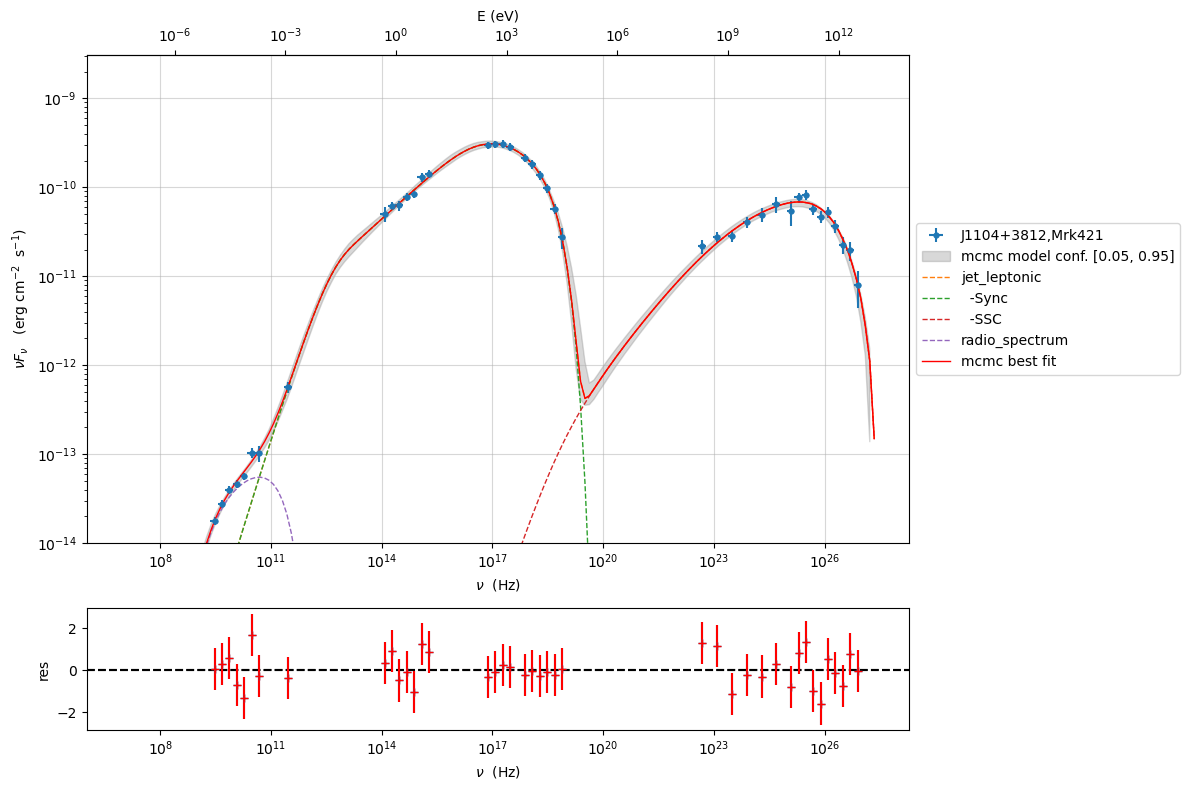

In [44]:
mpl.rcParams['figure.dpi'] = 80
p=mcmc.plot_model(sed_data=sed_data,fit_range=[1E7, 1E29],size=500,quantiles=[0.05,0.95],plot_components=True)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

To plot the frequentist  best-fit  model range,p roviding quantiles, provide (``plot_mcmc_best_fit_model==False``)

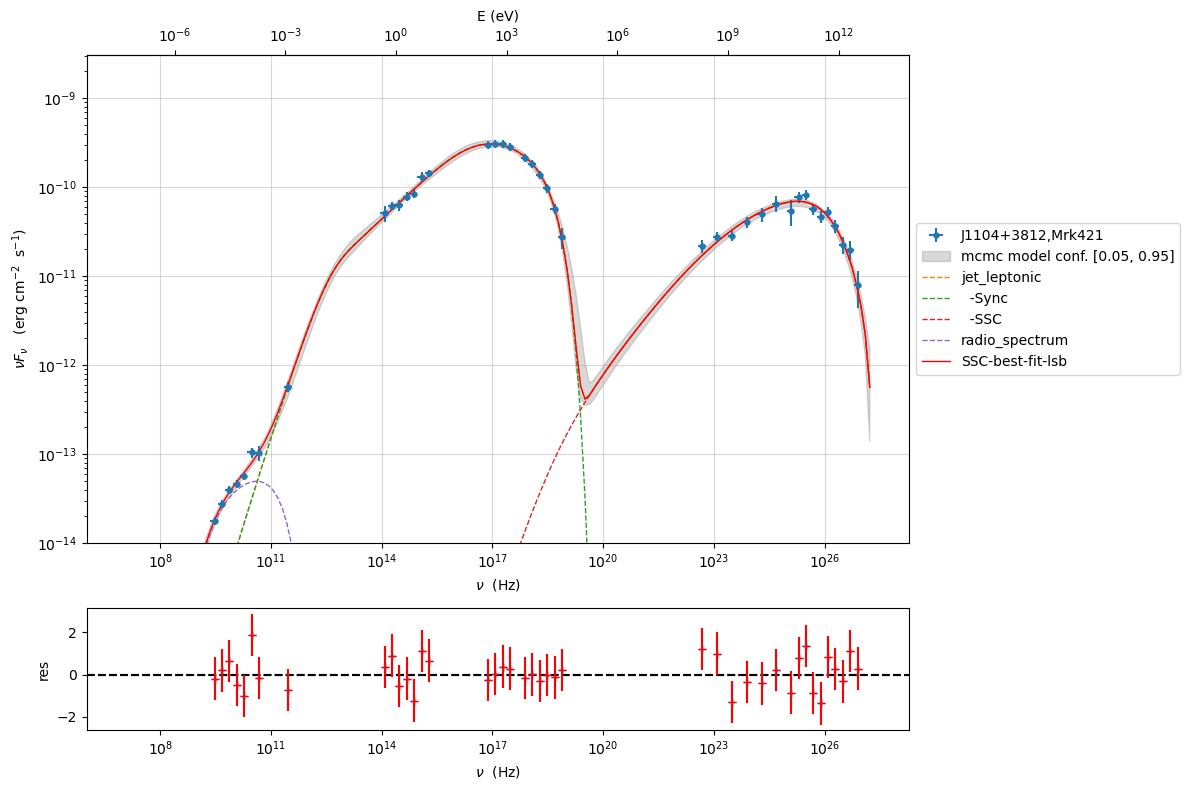

In [45]:
mpl.rcParams['figure.dpi'] = 100
p=mcmc.plot_model(sed_data=sed_data,fit_range=[1E7, 1E29],size=500,quantiles=[0.05,0.95], plot_mcmc_best_fit_model=False,plot_components=True)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

### plotting chains and individual posteriors

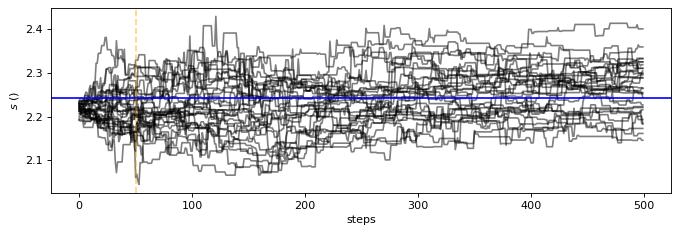

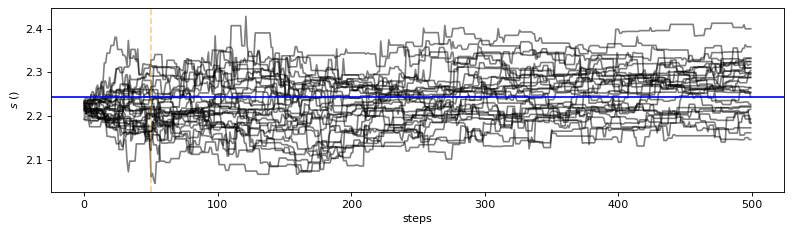

In [46]:
import matplotlib.pylab as plt

mpl.rcParams['figure.dpi'] = 80
f=mcmc.plot_chain(par_name='s',log_plot=False)
plt.tight_layout()

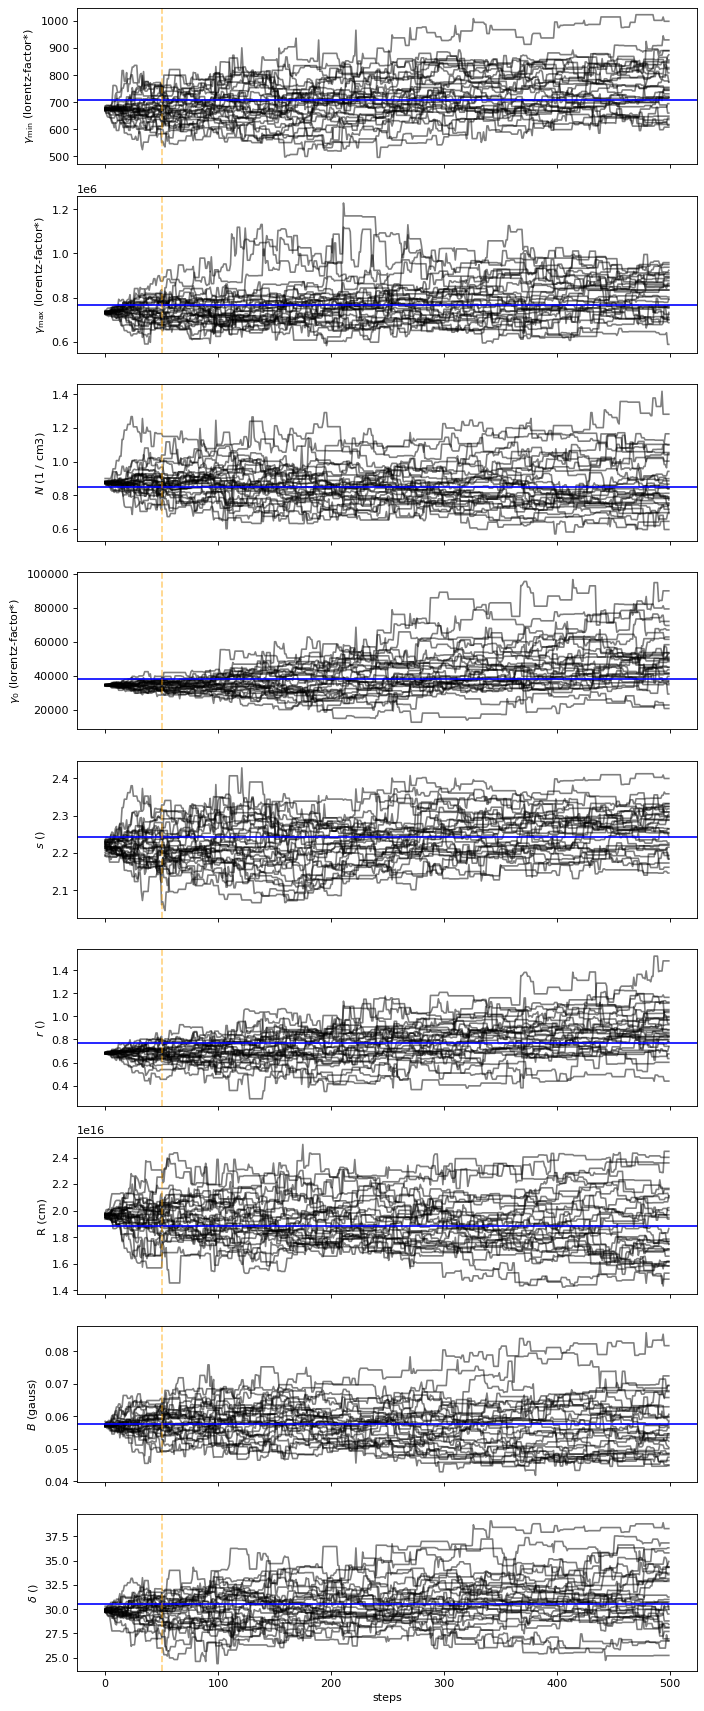

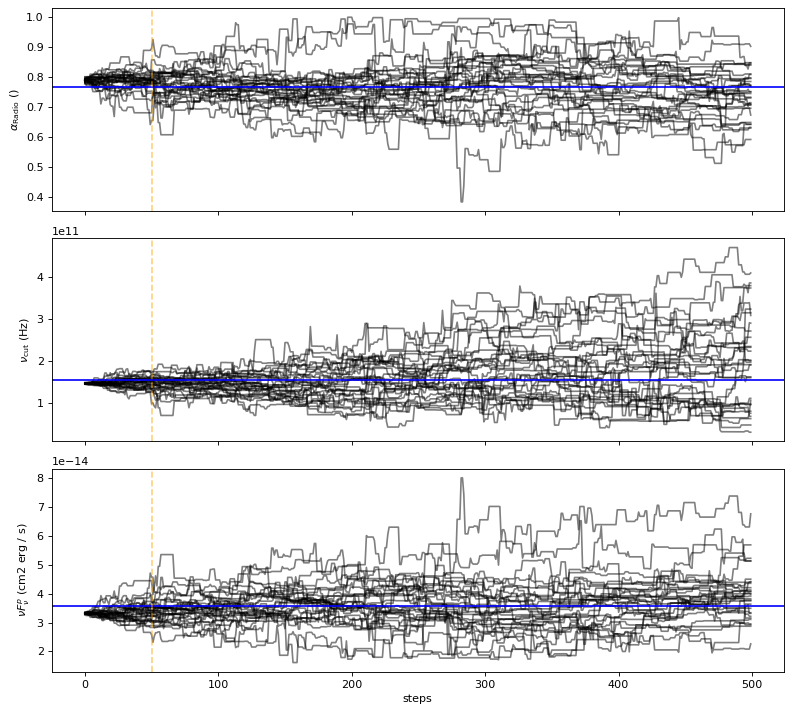

In [47]:
mpl.rcParams['figure.dpi'] = 80
f=mcmc.plot_chain(log_plot=False)
plt.tight_layout()

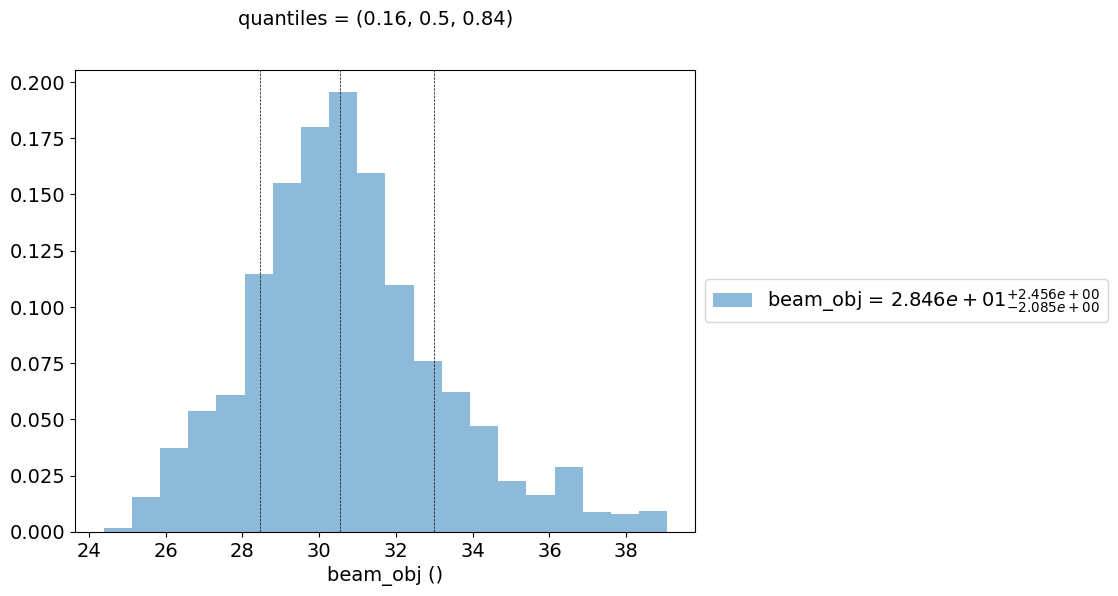

In [48]:

f=mcmc.plot_par('beam_obj',figsize=(8,6))
mpl.rcParams['figure.dpi'] = 80

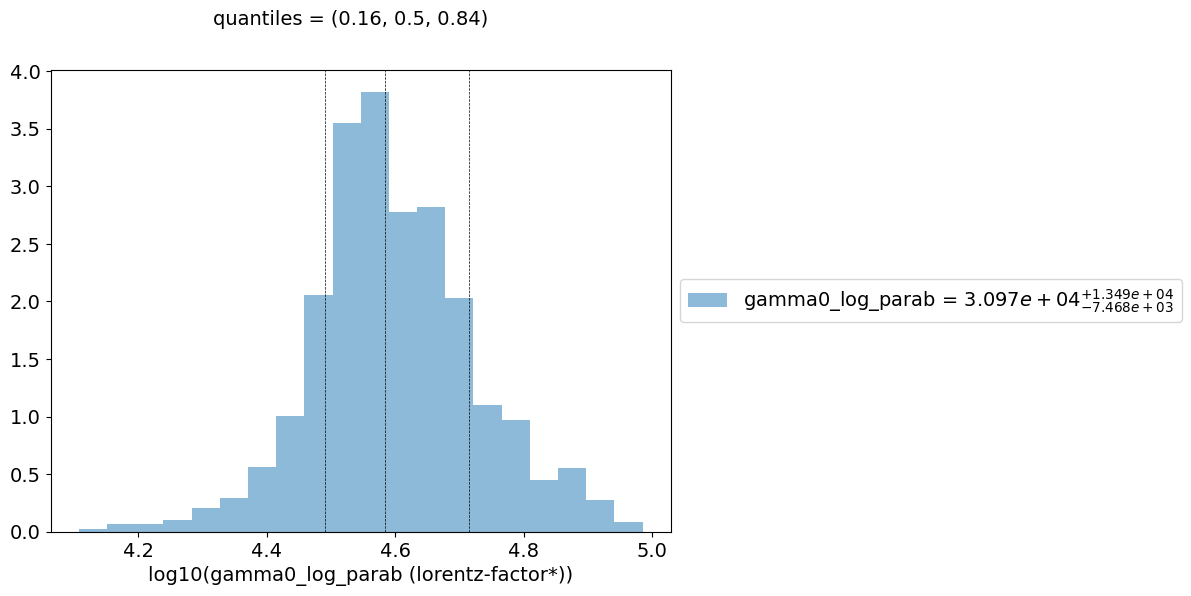

In [49]:
mpl.rcParams['figure.dpi'] = 80
f=mcmc.plot_par('gamma0_log_parab',log_plot=True,figsize=(8,6))

## Save and reuse MCMC

In [50]:
mcmc.save('mcmc_sampler.pkl')

In [51]:
from jetset.mcmc import McmcSampler
from jetset.data_loader import ObsData

sed_data=ObsData.load('Mrk_401.pkl')
ms=McmcSampler.load('mcmc_sampler.pkl')

import matplotlib as mpl


In [52]:
ms.sampler_parameters

model name,name,val,bestfit mcmc,q16,q50,q84,mcmc bound min,mcmc bound max,frozen
str14,str16,float64,float64,float64,float64,float64,float64,float64,bool
jet_leptonic,gmin,7.222354e+02,7.222354e+02,6.378292e+02,7.081196e+02,8.106961e+02,2.000000e+00,4.058209e+03,False
jet_leptonic,gmax,7.541714e+05,7.541714e+05,6.907358e+05,7.661786e+05,8.767773e+05,1.000000e+04,4.394968e+06,False
jet_leptonic,N,8.829585e-01,8.829585e-01,7.451434e-01,8.495691e-01,9.976606e-01,1.000000e-05,1.000000e+01,False
jet_leptonic,gamma0_log_parab,4.172550e+04,4.172550e+04,3.097231e+04,3.844031e+04,5.193165e+04,1.000000e+03,2.075563e+05,False
jet_leptonic,s,2.245824e+00,2.245824e+00,2.175121e+00,2.242416e+00,2.303833e+00,1.000000e+00,3.000000e+00,False
jet_leptonic,r,7.513979e-01,7.513979e-01,6.309326e-01,7.707346e-01,9.242154e-01,1.000000e-01,2.000000e+00,False
jet_leptonic,R,1.847903e+16,1.847903e+16,1.718877e+16,1.884292e+16,2.118421e+16,3.162278e+15,1.177195e+17,False
jet_leptonic,R_H,1.000000e+17,--,--,--,--,0.000000e+00,--,True
jet_leptonic,B,5.233642e-02,5.233642e-02,4.970970e-02,5.769336e-02,6.429220e-02,1.000000e-03,3.432523e-01,False


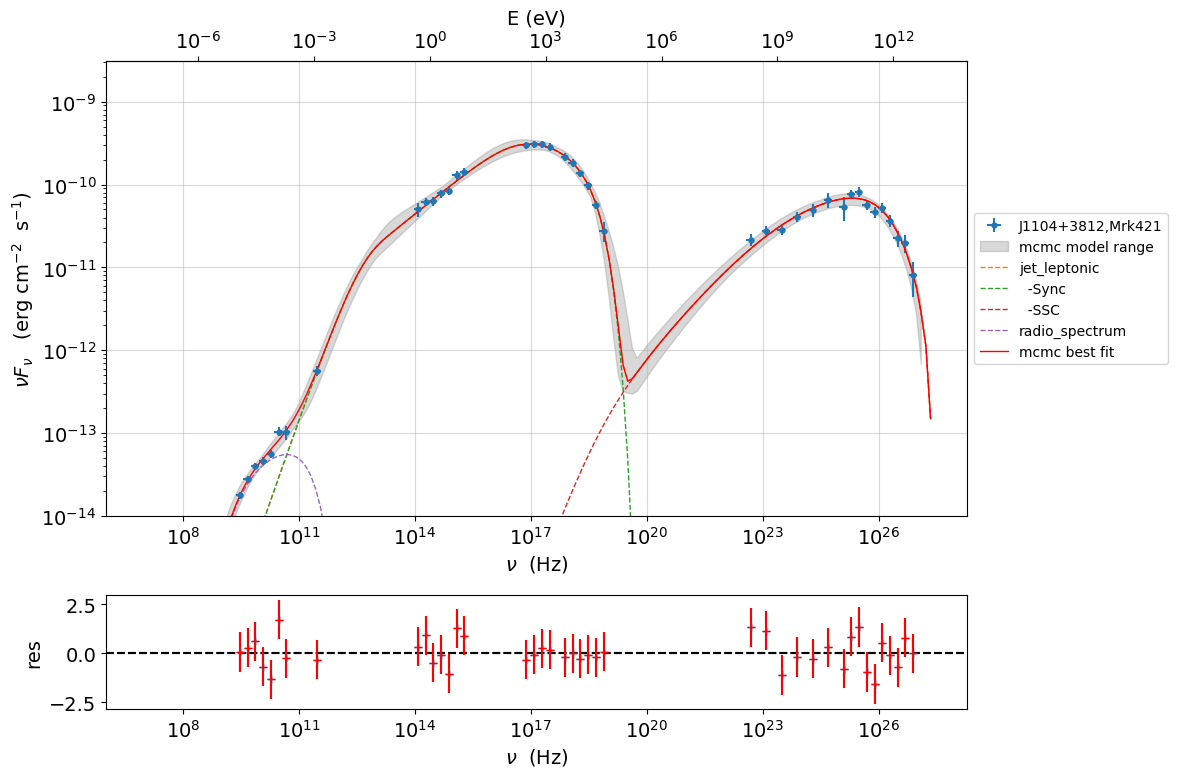

In [53]:
mpl.rcParams['figure.dpi'] = 80
p=ms.plot_model(sed_data=sed_data,fit_range=[1E7, 1E29],size=500,plot_components=True)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

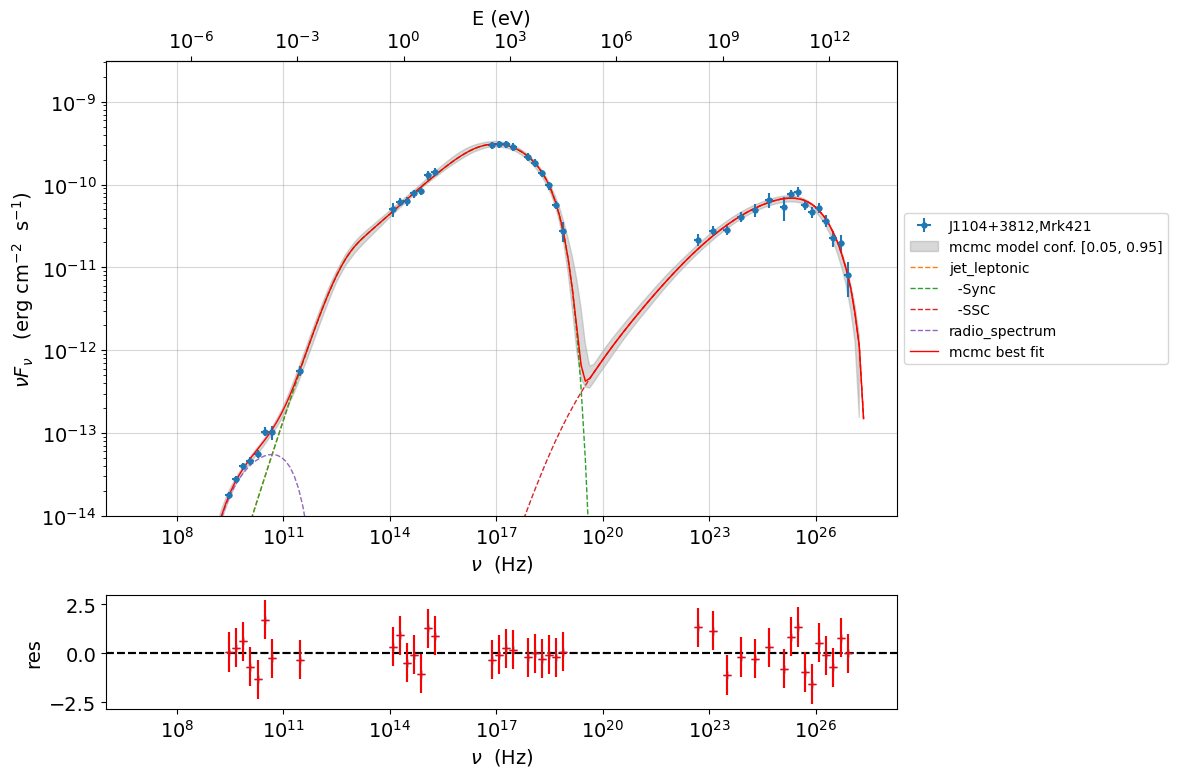

In [54]:
mpl.rcParams['figure.dpi'] = 80
p=ms.plot_model(sed_data=sed_data,fit_range=[1E7, 1E29],size=100,quantiles=[0.05,0.95],plot_components=True)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

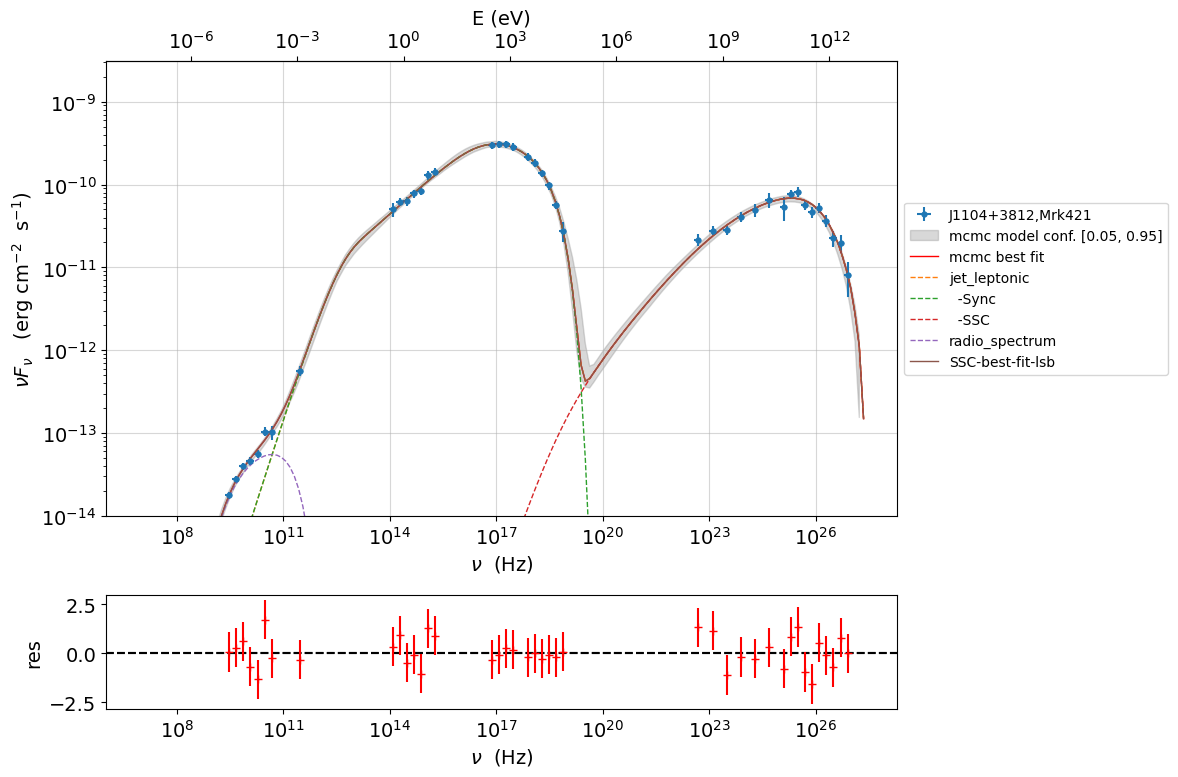

In [55]:
mpl.rcParams['figure.dpi'] = 80
p=ms.plot_model(sed_data=sed_data,fit_range=[1E7, 1E29],size=100,quantiles=[0.05,0.95],plot_mcmc_best_fit_model=True)
p=ms.model.plot_model(plot_obj=p)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

Per-component corner plot

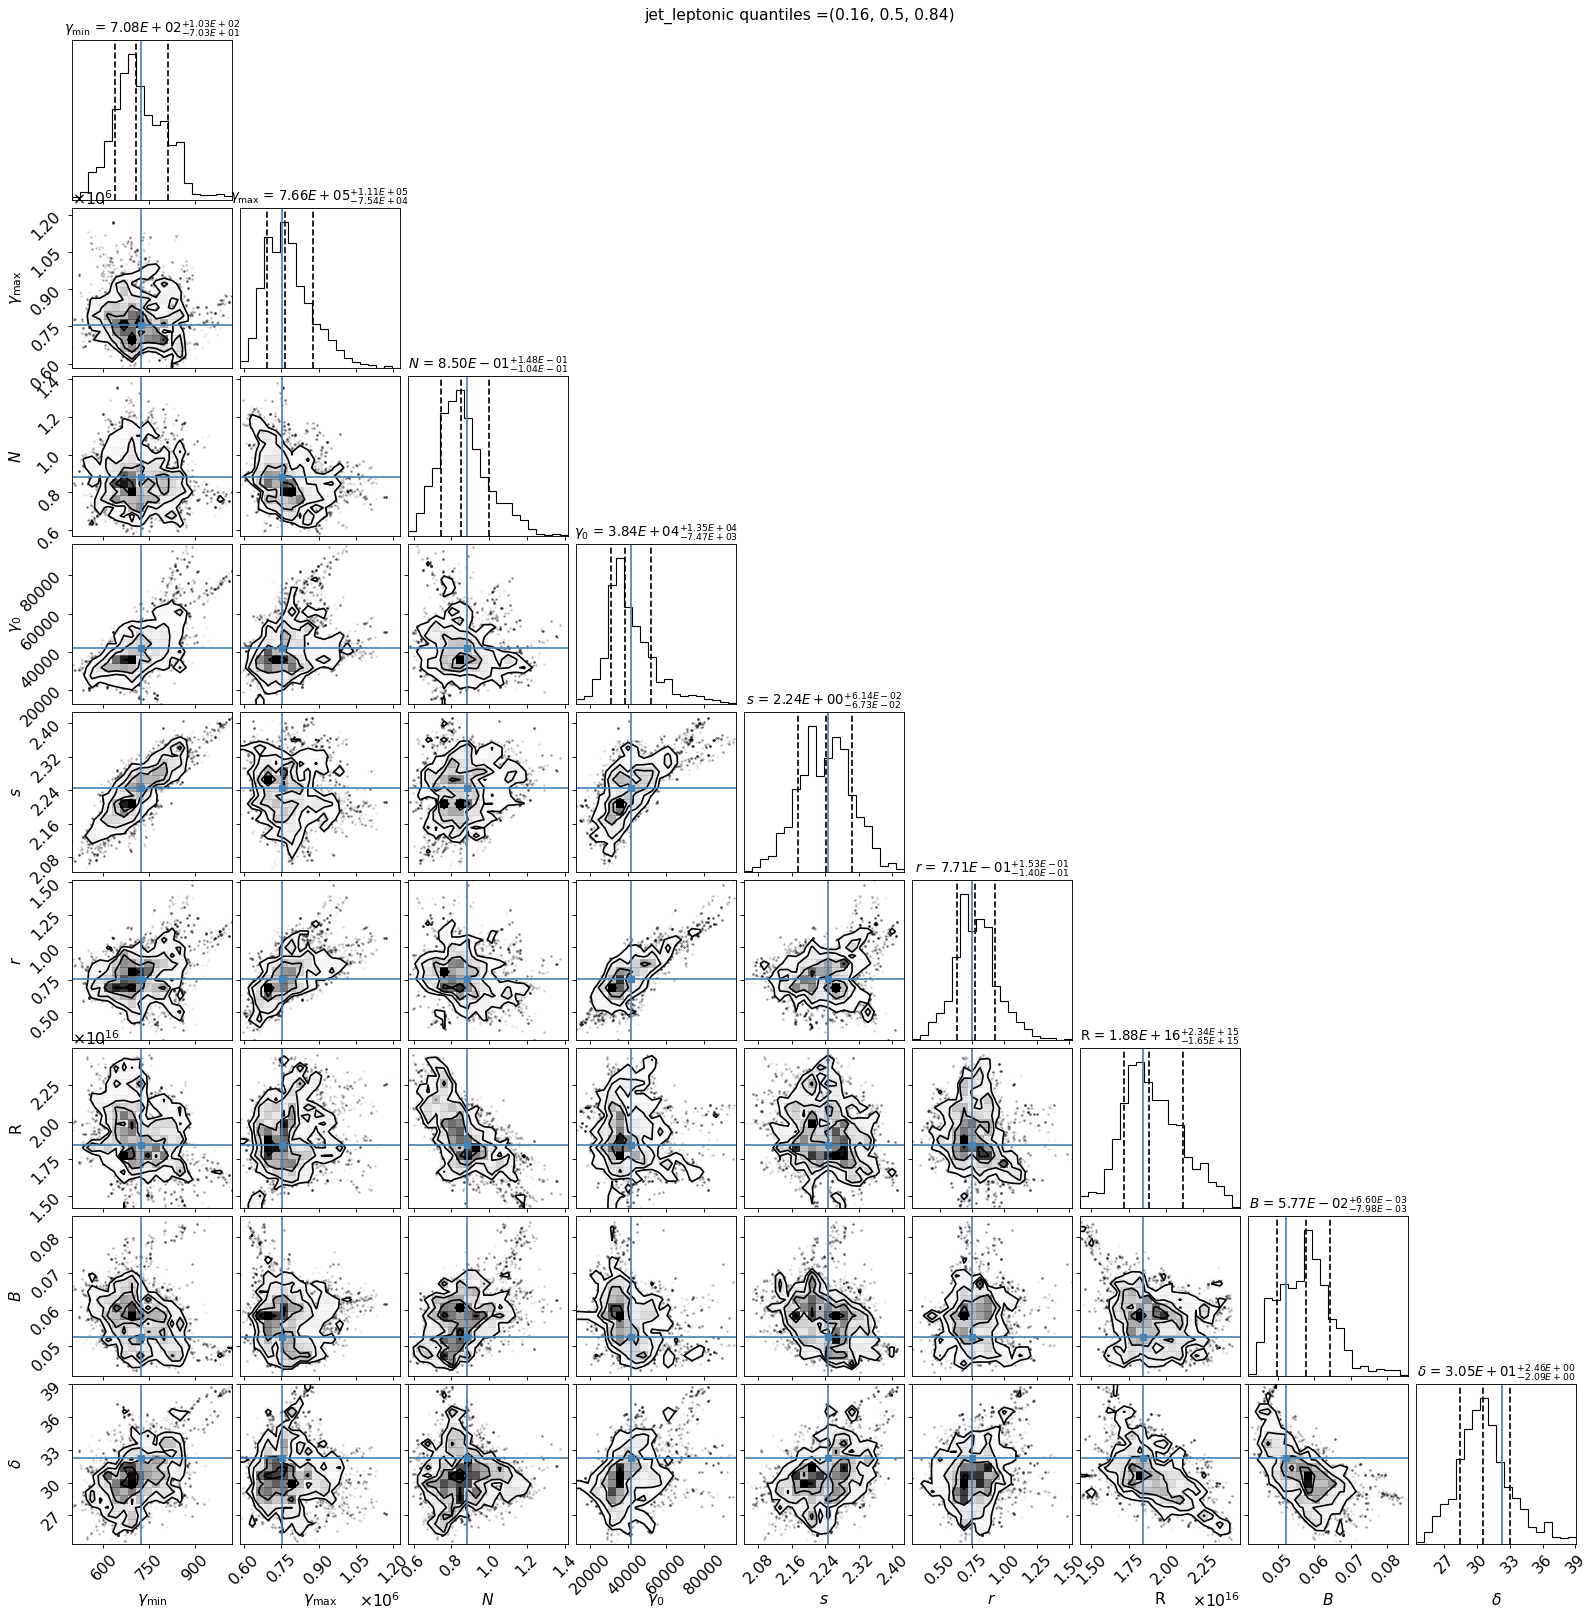

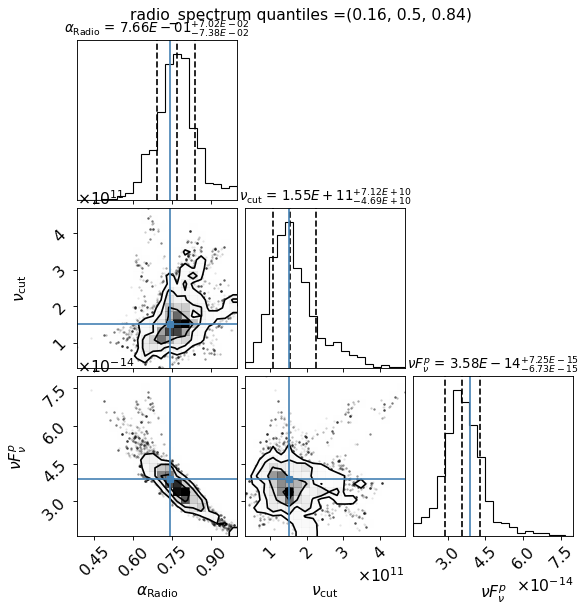

In [56]:
mpl.rcParams['figure.dpi'] = 80
f=ms.corner_plot(quantiles=(0.16, 0.5, 0.84),title_kwargs=dict(fontsize=12),title_fmt=".2E",use_math_text=True)

Global corner plot, pass `per_component=False`


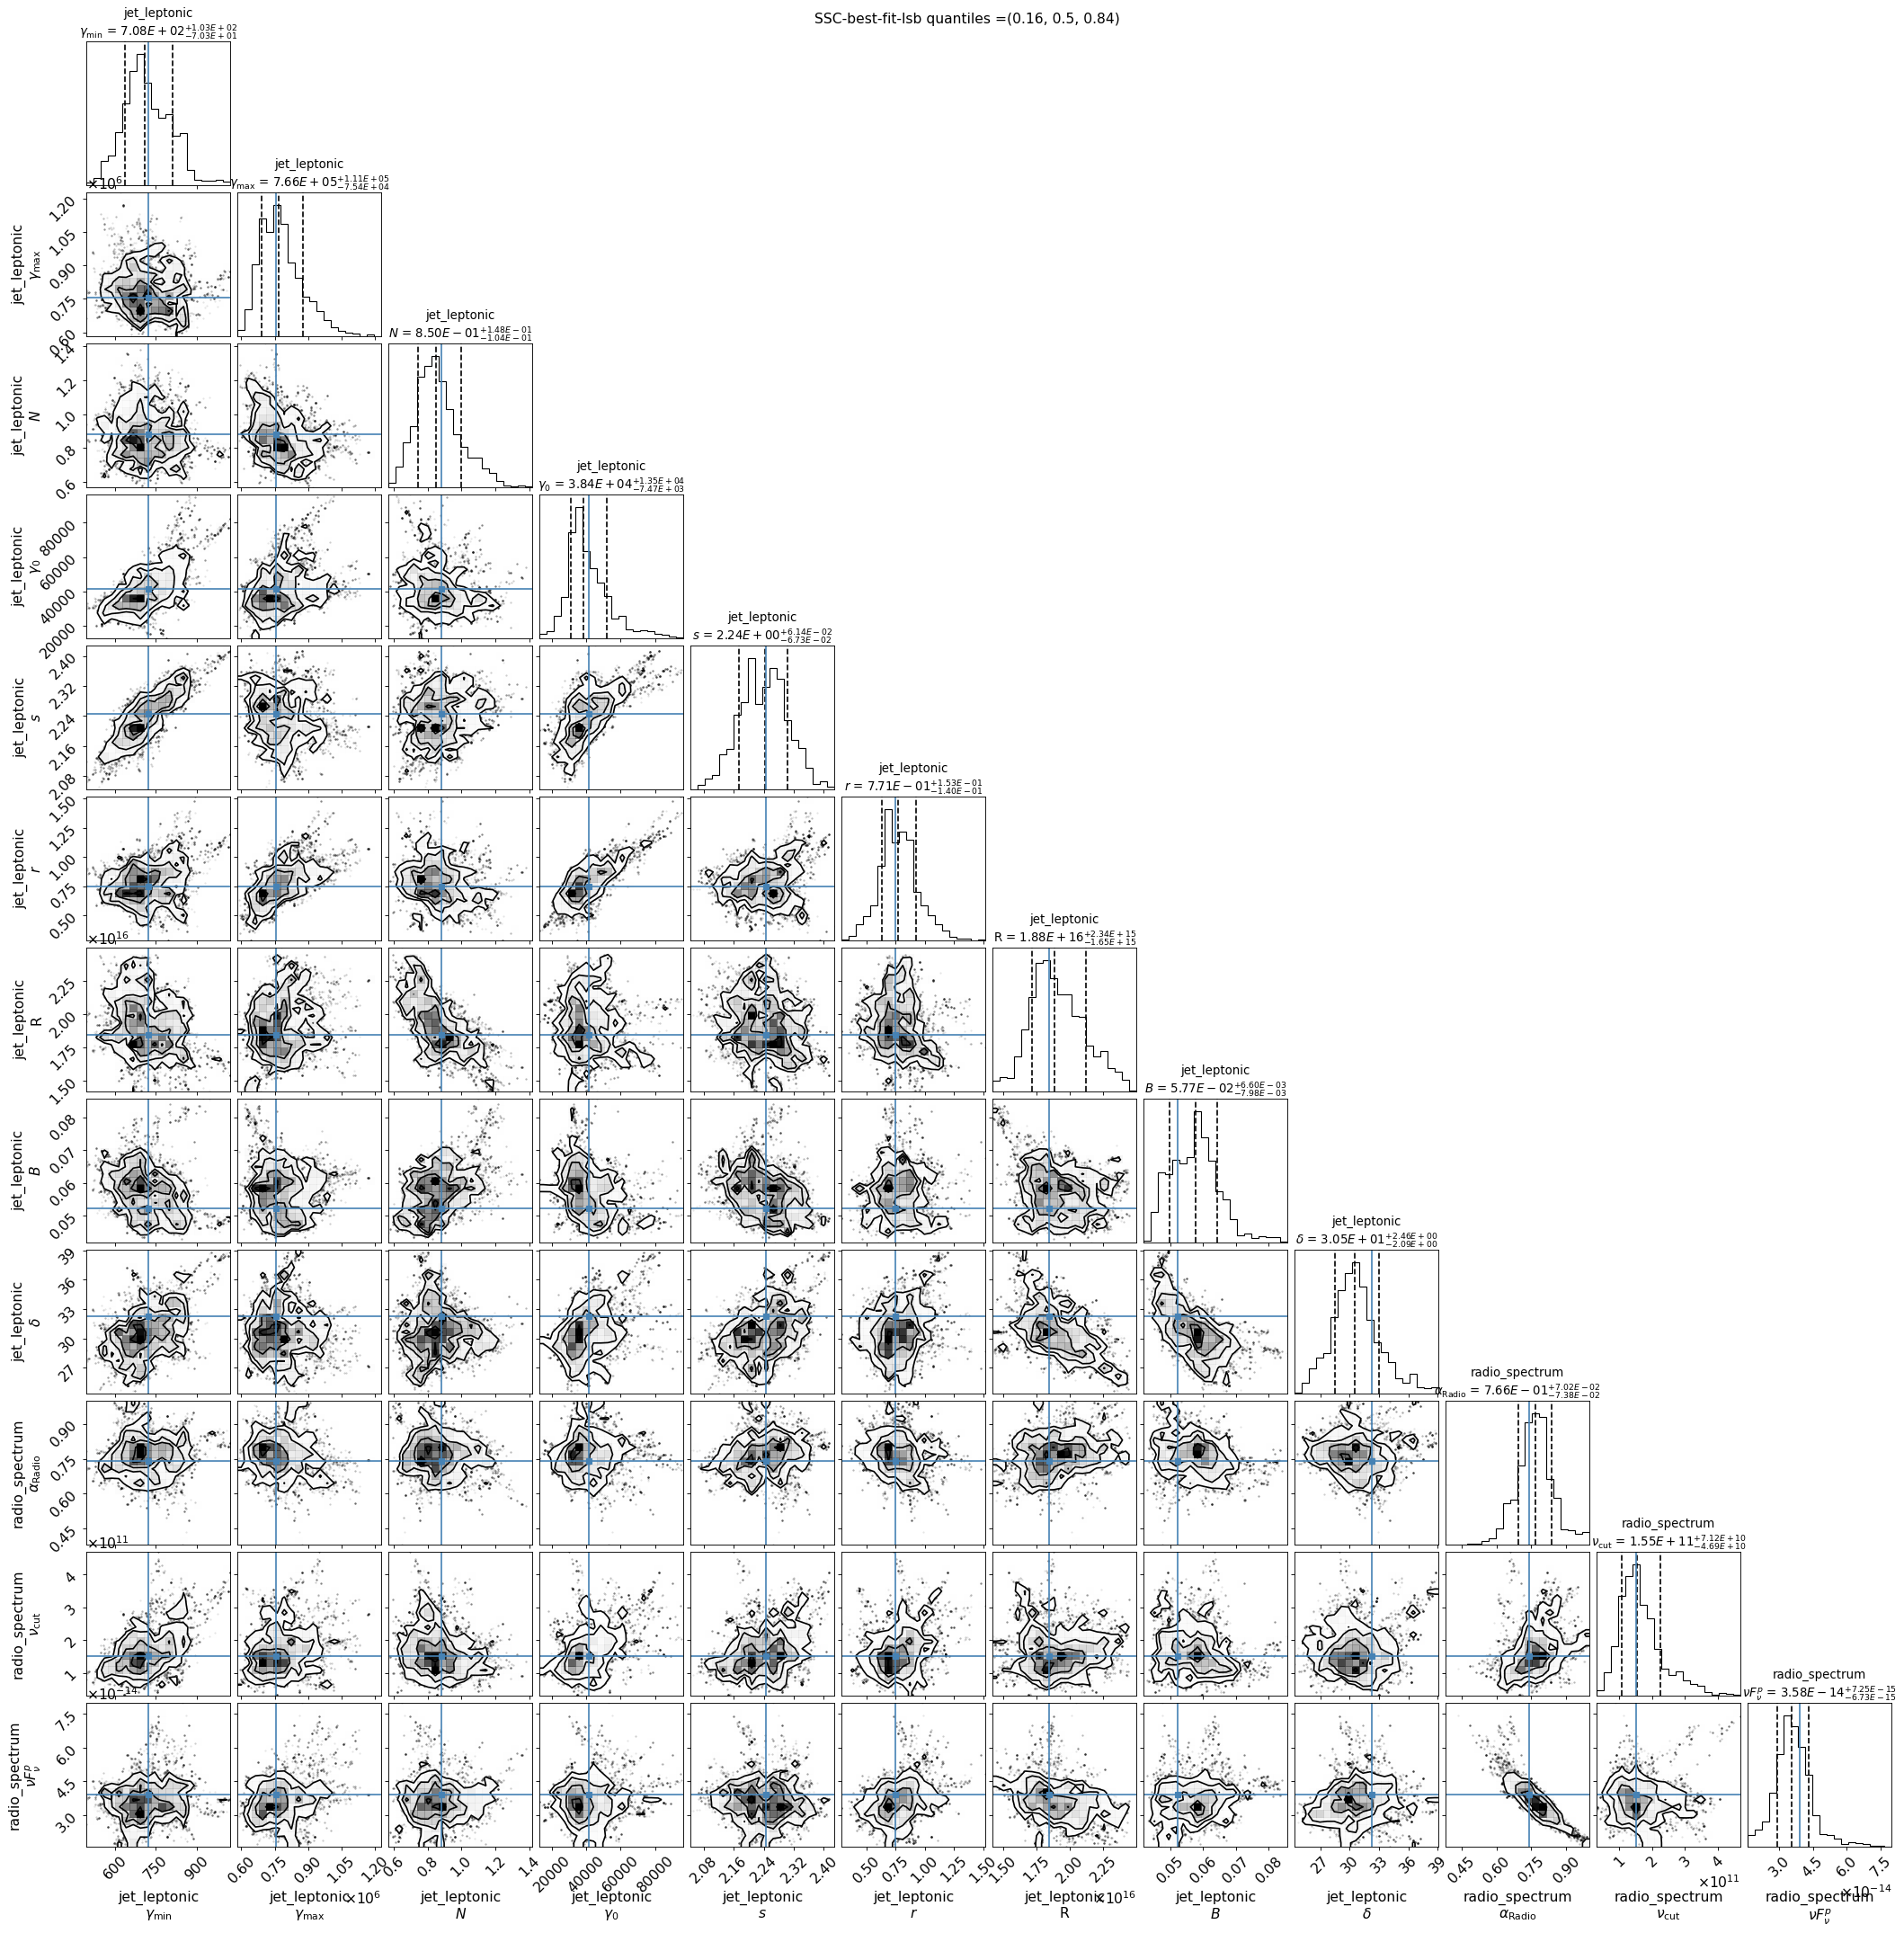

In [57]:
mpl.rcParams['figure.dpi'] = 80
f=ms.corner_plot(quantiles=(0.16, 0.5, 0.84),title_kwargs=dict(fontsize=12),title_fmt=".2E",use_math_text=True,per_component=False)

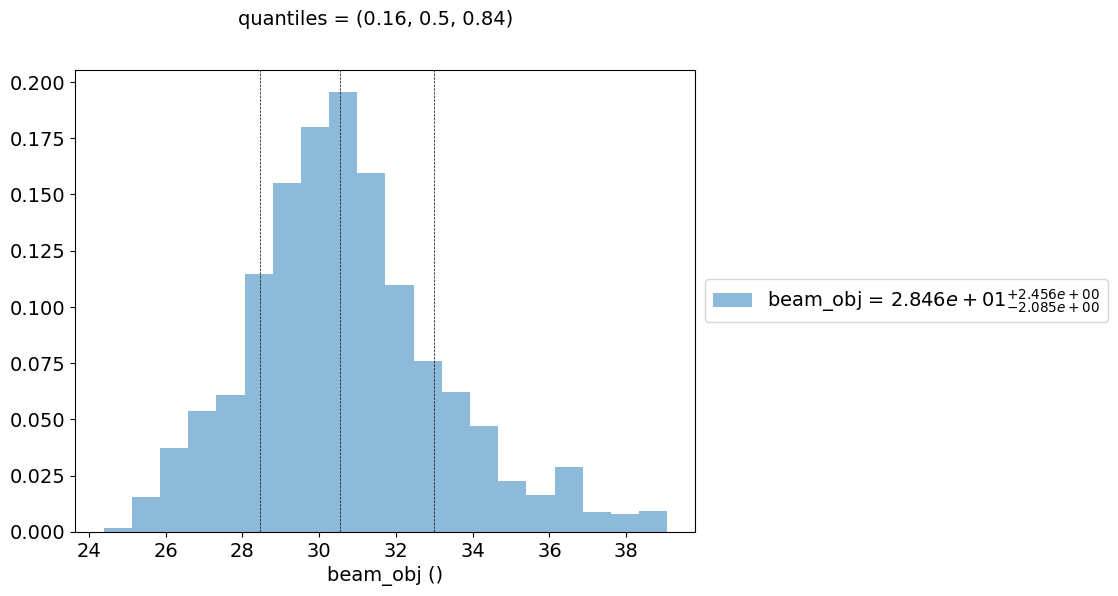

In [58]:
mpl.rcParams['figure.dpi'] = 80
f=ms.plot_par('beam_obj',log_plot=False,figsize=(8,6))

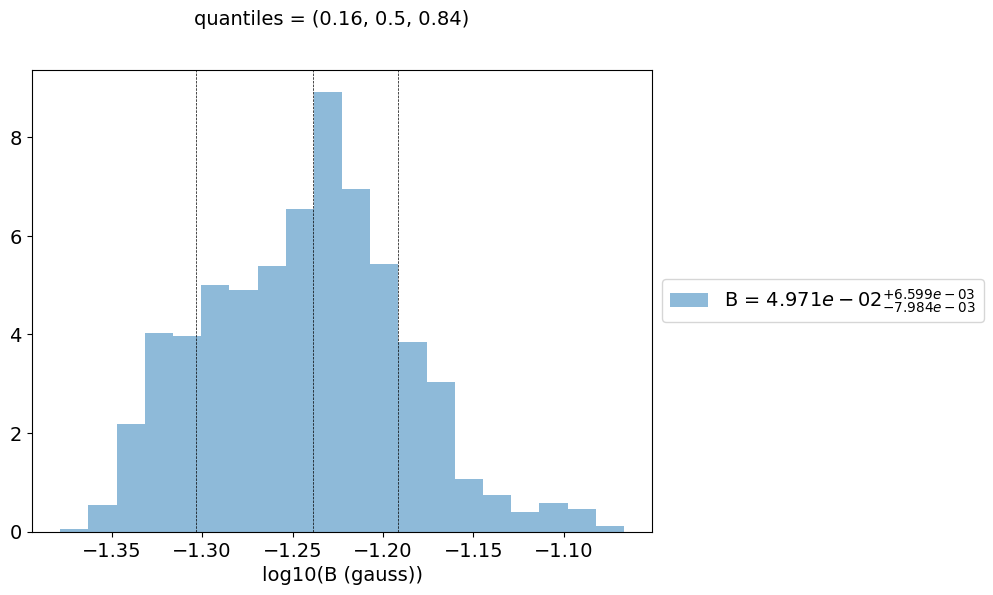

In [59]:
f=ms.plot_par('B',log_plot=True,figsize=(8,6))

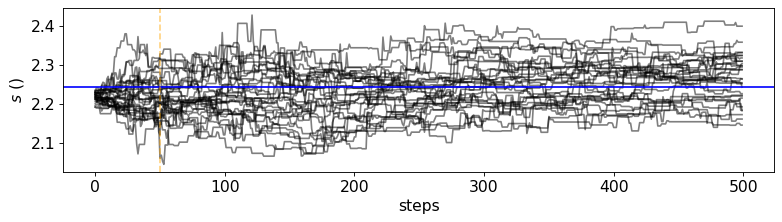

In [60]:
from matplotlib import pylab as plt
mpl.rcParams['figure.dpi'] = 80
f=ms.plot_chain(par_name='s',comp_name='jet_leptonic',log_plot=False)
plt.tight_layout()

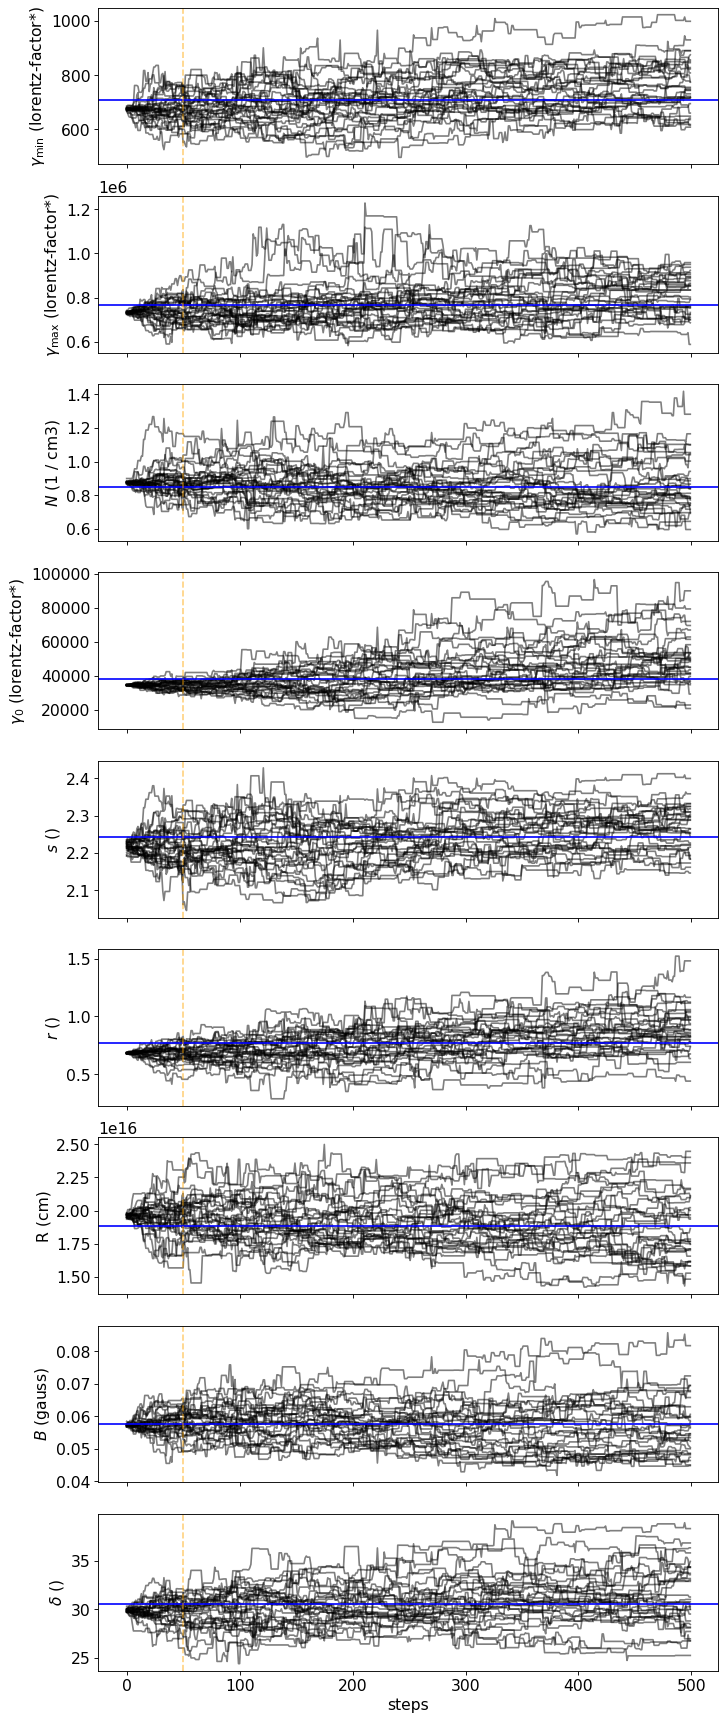

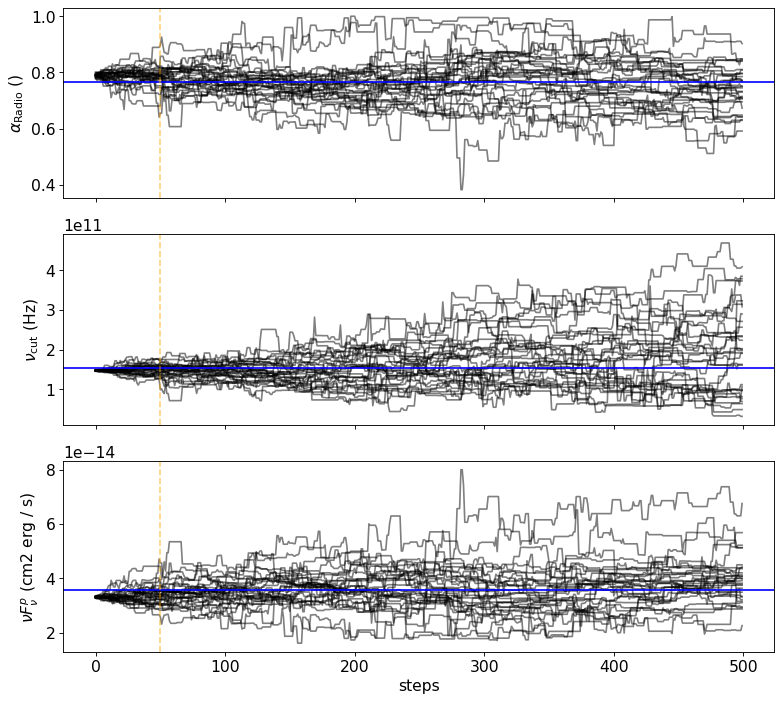

In [61]:
f=ms.plot_chain(log_plot=False)
plt.tight_layout()
mpl.rcParams['figure.dpi'] = 80